# Full EDA Notebook - Home Credit Default Risk

## 1. Project Overview

### 1.1 Objective

This notebook performs a focused and structured exploratory data analysis (EDA) for the Home Credit Default Risk project.

A structural audit has already been completed earlier. Therefore, this notebook is intentionally selective and practical.

The main goals of this notebook are:

1. Load and validate the train, test, and structural audit report files
2. Reuse the structural audit findings instead of repeating low-value checks
3. Build feature groups for focused analysis
4. Perform important univariate and bivariate analysis
5. Create selected pairwise visualizations instead of plotting everything
6. Review correlation, missingness, and redundancy
7. Build a practical feature engineering roadmap

### 1.2 Why this notebook is selective

This notebook is designed this way because:

- the structural audit is already completed
- time is limited
- this is a practice project
- only representative and useful visualizations should be created
- the notebook should remain readable and easy to run end-to-end

## 2. Setup and Configuration

In [45]:
# Standard library imports
import os
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy import stats

# Display helpers
from IPython.display import display, Markdown

In [46]:
# Pandas display settings
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Plot settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["legend.frameon"] = True

In [ ]:
# ==============================
# File path configuration
# ==============================

PROJECT_ROOT = next(
    (
        path
        for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
        if (path / "Notebook").exists() and (path / "Data").exists()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not locate the project root. Run this notebook from inside the cloned repository."
    )

REPORT_PATH = PROJECT_ROOT / "Report" / "9.master_consolidated_report.csv"
TRAIN_FILE_PATH = PROJECT_ROOT / "Data" / "Processed" / "final_train_before_eda.csv"
TEST_FILE_PATH = PROJECT_ROOT / "Data" / "Processed" / "final_test_before_eda.csv"

TARGET_COL = "TARGET"
ID_COL = "SK_ID_CURR"   # Change this only if your ID column is different
RANDOM_STATE = 42

# Plot controls for a time-efficient EDA
MAX_CONTINUOUS_PLOTS = 8
MAX_DISCRETE_PLOTS = 6
MAX_CATEGORICAL_PLOTS = 8
MAX_NUMERIC_TARGET_PLOTS = 8
MAX_CATEGORICAL_TARGET_PLOTS = 8


In [48]:
# Quick path validation
for file_name, file_path in {
    "REPORT_PATH": REPORT_PATH,
    "TRAIN_FILE_PATH": TRAIN_FILE_PATH,
    "TEST_FILE_PATH": TEST_FILE_PATH
}.items():
    exists = os.path.exists(file_path)
    print(f"{file_name}: {'Found' if exists else 'Not Found'}")

REPORT_PATH: Found
TRAIN_FILE_PATH: Found
TEST_FILE_PATH: Found


## 3. Helper Functions

In [49]:
def existing_cols(df, cols):
    """Return only the columns that exist in the dataframe."""
    return [col for col in cols if col in df.columns]


def print_shape(df, name="DataFrame"):
    """Print dataframe shape in a readable format."""
    print(f"{name} shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")


def quick_feature_summary(df, col):
    """Return a quick summary table for a single feature."""
    summary = {
        "column": col,
        "dtype": str(df[col].dtype),
        "missing_count": int(df[col].isnull().sum()),
        "missing_pct": round(df[col].isnull().mean() * 100, 2),
        "nunique": int(df[col].nunique(dropna=False))
    }
    if pd.api.types.is_numeric_dtype(df[col]):
        summary.update({
            "min": df[col].min(),
            "max": df[col].max(),
            "mean": df[col].mean(),
            "median": df[col].median(),
            "std": df[col].std()
        })
    return pd.DataFrame([summary])


def split_numeric_columns(df, numeric_cols, unique_threshold=20):
    """
    Split numeric columns into continuous-like and discrete-like groups.
    A simple practical rule is used here to keep the notebook fast and readable.
    """
    continuous_cols = []
    discrete_cols = []

    for col in numeric_cols:
        nunique = df[col].nunique(dropna=True)
        if nunique <= unique_threshold:
            discrete_cols.append(col)
        else:
            continuous_cols.append(col)

    return continuous_cols, discrete_cols


def build_missing_summary(df):
    """Create a missing value summary table."""
    missing_df = pd.DataFrame({
        "column": df.columns,
        "missing_count": df.isnull().sum().values,
        "missing_pct": (df.isnull().mean().values * 100)
    }).sort_values(["missing_pct", "missing_count"], ascending=[False, False]).reset_index(drop=True)
    return missing_df


def build_zero_summary(df, cols):
    """Create a zero-percentage summary for numeric columns."""
    rows = []
    for col in cols:
        try:
            zero_pct = (df[col] == 0).mean() * 100
        except Exception:
            zero_pct = np.nan
        rows.append({"column": col, "zero_pct": zero_pct})
    return pd.DataFrame(rows).sort_values("zero_pct", ascending=False).reset_index(drop=True)


def get_report_column(report_df, candidates):
    """Return the first matching report column name from a list of candidates."""
    for c in candidates:
        if c in report_df.columns:
            return c
    return None

In [50]:
def plot_top_missing(missing_df, top_n=20):
    """Plot top missing columns."""
    top_missing = missing_df[missing_df["missing_count"] > 0].head(top_n)
    if top_missing.empty:
        print("No missing values found.")
        return

    plt.figure(figsize=(12, 7))
    sns.barplot(data=top_missing, x="missing_pct", y="column")
    plt.title(f"Top {min(top_n, len(top_missing))} Columns by Missing Percentage")
    plt.xlabel("Missing Percentage")
    plt.ylabel("Column")
    plt.tight_layout()
    plt.show()


def plot_missing_pattern_heatmap(df, missing_df=None, top_n=15, sample_size=2500):
    """Visualize the missingness pattern for the most incomplete columns."""
    if missing_df is None:
        missing_df = build_missing_summary(df)

    cols = missing_df.loc[missing_df["missing_pct"] > 0, "column"].head(top_n).tolist()
    if not cols:
        print("No missing columns available for the heatmap.")
        return

    temp = df[cols].isnull().astype(int)
    if len(temp) > sample_size:
        temp = temp.sample(sample_size, random_state=RANDOM_STATE)

    temp = temp.sort_values(by=cols, ascending=False)

    plt.figure(figsize=(max(10, len(temp) * 0.01), max(4, len(cols) * 0.45)))
    sns.heatmap(temp.T, cmap="Reds", cbar=False, vmin=0, vmax=1, xticklabels=False)
    plt.title(f"Missingness Pattern Heatmap for Top {len(cols)} Columns")
    plt.xlabel("Sampled Rows")
    plt.ylabel("Column")
    plt.tight_layout()
    plt.show()


def plot_numeric_distribution(df, col):
    """Plot histogram and boxplot for a numeric feature."""
    temp = df[col].dropna()
    if temp.empty:
        print(f"{col}: no non-null values available.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    sns.histplot(temp, kde=True, ax=axes[0])
    axes[0].set_title(f"{col} - Histogram")

    sns.boxplot(x=temp, ax=axes[1])
    axes[1].set_title(f"{col} - Boxplot")

    plt.tight_layout()
    plt.show()

    skew_val = temp.skew()
    print(f"{col} | missing%={df[col].isnull().mean()*100:.2f} | skewness={skew_val:.3f} | nunique={df[col].nunique(dropna=True)}")


def plot_top_skewed_features(df, cols, top_n=10):
    """Plot the most skewed numeric features from a selected list."""
    rows = []

    for col in cols:
        if col not in df.columns or not pd.api.types.is_numeric_dtype(df[col]):
            continue

        temp = df[col].dropna()
        if temp.empty or temp.nunique() <= 2:
            continue

        rows.append({
            "column": col,
            "skewness": temp.skew(),
            "abs_skew": abs(temp.skew()),
            "missing_pct": df[col].isnull().mean() * 100
        })

    result = pd.DataFrame(rows).sort_values("abs_skew", ascending=False).reset_index(drop=True)
    if result.empty:
        print("No eligible numeric features found for skewness plotting.")
        return

    top_result = result.head(top_n).copy()
    top_result = top_result.sort_values("skewness")

    plt.figure(figsize=(10, max(4, len(top_result) * 0.45)))
    plt.barh(top_result["column"], top_result["skewness"], color="#4c72b0")
    plt.axvline(0, color="black", linewidth=1)
    plt.title(f"Top {len(top_result)} Skewed Continuous Features")
    plt.xlabel("Skewness")
    plt.ylabel("Column")
    plt.tight_layout()
    plt.show()

    display(result.head(top_n))


def plot_discrete_distribution(df, col, top_n=20):
    """Plot count distribution for a discrete numeric feature."""
    vc = df[col].value_counts(dropna=False).head(top_n).sort_index()
    if vc.empty:
        print(f"{col}: no values available.")
        return

    plt.figure(figsize=(10, 4))
    sns.barplot(x=vc.index.astype(str), y=vc.values)
    plt.title(f"{col} - Value Counts")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    print(f"{col} | missing%={df[col].isnull().mean()*100:.2f} | nunique={df[col].nunique(dropna=False)}")


def plot_categorical_distribution(df, col, top_n=15):
    """Plot count distribution for a categorical feature."""
    vc = df[col].fillna("Missing").astype(str).value_counts().head(top_n)
    if vc.empty:
        print(f"{col}: no values available.")
        return

    plt.figure(figsize=(10, 5))
    sns.barplot(x=vc.values, y=vc.index)
    plt.title(f"{col} - Top Categories")
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

    print(f"{col} | missing%={df[col].isnull().mean()*100:.2f} | nunique={df[col].nunique(dropna=False)}")


def plot_zero_ratio_bars(zero_summary_df, top_n=12):
    """Plot the most zero-dominant numeric features."""
    temp = zero_summary_df.dropna().sort_values("zero_pct", ascending=False).head(top_n)
    if temp.empty:
        print("No zero-ratio information available.")
        return

    plt.figure(figsize=(10, max(4, len(temp) * 0.45)))
    sns.barplot(data=temp, x="zero_pct", y="column")
    plt.title(f"Top {len(temp)} Zero-Dominant Numeric Features")
    plt.xlabel("Zero Percentage")
    plt.ylabel("Column")
    plt.tight_layout()
    plt.show()


In [51]:
def plot_numeric_vs_target(df, col, target_col, q=10):
    """Plot numeric feature against target using boxplot and binned target rate."""
    if col not in df.columns or target_col not in df.columns:
        return

    temp = df[[col, target_col]].dropna().copy()
    if temp.empty:
        print(f"{col}: no data available after dropping missing values.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    sns.boxplot(data=temp, x=target_col, y=col, ax=axes[0])
    axes[0].set_title(f"{col} vs {target_col} - Boxplot")

    try:
        temp["bin"] = pd.qcut(temp[col], q=q, duplicates="drop")
        rate_df = temp.groupby("bin")[target_col].mean().reset_index()
        rate_df["bin"] = rate_df["bin"].astype(str)

        sns.lineplot(data=rate_df, x="bin", y=target_col, marker="o", ax=axes[1])
        axes[1].set_title(f"{col} - Target Rate by Quantile Bin")
        axes[1].tick_params(axis="x", rotation=75)
        axes[1].set_ylabel(f"Mean {target_col}")
    except Exception:
        sns.kdeplot(data=temp, x=col, hue=target_col, fill=True, common_norm=False, ax=axes[1])
        axes[1].set_title(f"{col} vs {target_col} - KDE")

    plt.tight_layout()
    plt.show()


def plot_categorical_vs_target(df, col, target_col, top_n=12):
    """Plot category distribution and target rate for a categorical feature."""
    if col not in df.columns or target_col not in df.columns:
        return

    temp = df[[col, target_col]].copy()
    temp[col] = temp[col].fillna("Missing").astype(str)

    top_categories = temp[col].value_counts().head(top_n).index
    temp = temp[temp[col].isin(top_categories)].copy()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    sns.countplot(data=temp, y=col, hue=target_col, order=temp[col].value_counts().index, ax=axes[0])
    axes[0].set_title(f"{col} vs {target_col} - Countplot")

    rate_df = temp.groupby(col)[target_col].mean().sort_values(ascending=False).reset_index()
    sns.barplot(data=rate_df, x=target_col, y=col, ax=axes[1])
    axes[1].set_title(f"{col} - Mean {target_col} by Category")
    axes[1].set_xlabel(f"Mean {target_col}")

    plt.tight_layout()
    plt.show()


def plot_target_correlation_bar(df, cols, target_col, top_n=15, method="spearman"):
    """Plot the strongest numeric correlations with the target."""
    if target_col not in df.columns:
        print("Target column not available.")
        return

    rows = []
    seen = set()

    for col in cols:
        if col in seen or col == target_col:
            continue
        seen.add(col)

        if col not in df.columns or not pd.api.types.is_numeric_dtype(df[col]):
            continue

        temp = df[[col, target_col]].dropna()
        if temp.empty or temp[col].nunique() <= 1:
            continue

        corr_val = temp[col].corr(temp[target_col], method=method)
        if pd.isna(corr_val):
            continue

        rows.append({
            "column": col,
            "corr": corr_val,
            "abs_corr": abs(corr_val),
            "missing_pct": df[col].isnull().mean() * 100
        })

    result = pd.DataFrame(rows).sort_values("abs_corr", ascending=False).reset_index(drop=True)
    if result.empty:
        print("No eligible numeric features found for target correlation plotting.")
        return

    top_result = result.head(top_n).copy()
    top_result = top_result.sort_values("corr")
    colors = ["#c44e52" if val > 0 else "#55a868" for val in top_result["corr"]]

    plt.figure(figsize=(10, max(4, len(top_result) * 0.45)))
    plt.barh(top_result["column"], top_result["corr"], color=colors)
    plt.axvline(0, color="black", linewidth=1)
    plt.title(f"Top {len(top_result)} Numeric Features by Correlation with {target_col}")
    plt.xlabel(f"{method.title()} Correlation")
    plt.ylabel("Column")
    plt.tight_layout()
    plt.show()

    display(result.head(top_n))


def plot_categorical_target_heatmap(df, row_col, col_col, target_col, top_n_row=8, top_n_col=6, min_count=200):
    """Plot a categorical interaction heatmap using mean target rate."""
    required_cols = [row_col, col_col, target_col]
    if any(col not in df.columns for col in required_cols):
        print(f"Skipping heatmap for ({row_col}, {col_col}) because one or more columns are missing.")
        return

    temp = df[required_cols].copy()
    temp[row_col] = temp[row_col].fillna("Missing").astype(str)
    temp[col_col] = temp[col_col].fillna("Missing").astype(str)

    top_rows = temp[row_col].value_counts().head(top_n_row).index
    top_cols = temp[col_col].value_counts().head(top_n_col).index
    temp = temp[temp[row_col].isin(top_rows) & temp[col_col].isin(top_cols)].copy()

    if temp.empty:
        print(f"No eligible rows available for ({row_col}, {col_col}).")
        return

    rate_pivot = temp.pivot_table(index=row_col, columns=col_col, values=target_col, aggfunc="mean")
    count_pivot = temp.pivot_table(index=row_col, columns=col_col, values=target_col, aggfunc="size", fill_value=0)

    rate_pivot = rate_pivot.reindex(index=top_rows, columns=top_cols)
    count_pivot = count_pivot.reindex(index=top_rows, columns=top_cols).fillna(0)

    rate_pivot = rate_pivot.mask(count_pivot < min_count)
    if rate_pivot.notnull().sum().sum() == 0:
        print(f"Not enough support to render ({row_col}, {col_col}) after applying min_count={min_count}.")
        return

    plt.figure(figsize=(max(7, len(top_cols) * 1.2), max(4, len(top_rows) * 0.55)))
    sns.heatmap(rate_pivot, annot=True, fmt=".3f", cmap="YlOrRd", linewidths=0.5)
    plt.title(f"Mean {target_col}: {row_col} x {col_col}")
    plt.xlabel(col_col)
    plt.ylabel(row_col)
    plt.tight_layout()
    plt.show()


In [52]:
def plot_scatter_pair(df, x_col, y_col, hue_col=None, max_sample=30000):
    """Plot a scatterplot for a selected pair of numeric features."""
    if x_col not in df.columns or y_col not in df.columns:
        return

    cols = [x_col, y_col]
    if hue_col and hue_col in df.columns:
        cols.append(hue_col)

    temp = df[cols].dropna().copy()
    if temp.empty:
        print(f"Pair ({x_col}, {y_col}) has no valid rows after dropping missing values.")
        return

    if len(temp) > max_sample:
        temp = temp.sample(max_sample, random_state=RANDOM_STATE)

    plt.figure(figsize=(7, 5))
    sns.scatterplot(
        data=temp,
        x=x_col,
        y=y_col,
        hue=hue_col if hue_col in temp.columns else None,
        alpha=0.35,
        s=18,
        edgecolor=None
    )
    plt.title(f"{x_col} vs {y_col}")
    plt.tight_layout()
    plt.show()


def plot_density_pair(df, x_col, y_col, max_sample=60000, gridsize=35):
    """Plot a hexbin density view for a selected numeric pair."""
    if x_col not in df.columns or y_col not in df.columns:
        return

    temp = df[[x_col, y_col]].dropna().copy()
    if temp.empty:
        print(f"Pair ({x_col}, {y_col}) has no valid rows for the density view.")
        return

    if len(temp) > max_sample:
        temp = temp.sample(max_sample, random_state=RANDOM_STATE)

    plt.figure(figsize=(7, 5))
    hb = plt.hexbin(temp[x_col], temp[y_col], gridsize=gridsize, cmap="viridis", mincnt=1, bins="log")
    plt.colorbar(hb, label="log10(count)")
    plt.title(f"{x_col} vs {y_col} - Density View")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.tight_layout()
    plt.show()


def plot_corr_heatmap(df, cols, title="Correlation Heatmap", method="spearman"):
    """Plot a correlation heatmap for a given set of numeric columns."""
    cols = [col for col in cols if col in df.columns and pd.api.types.is_numeric_dtype(df[col])]
    if len(cols) < 2:
        print(f"Not enough numeric columns available for: {title}")
        return

    corr = df[cols].corr(method=method)
    plt.figure(figsize=(max(8, len(cols) * 0.8), max(6, len(cols) * 0.6)))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
    plt.title(title)
    plt.tight_layout()
    plt.show()


def get_high_corr_pairs(df, cols, threshold=0.90, method="spearman"):
    """Return highly correlated pairs from a selected set of numeric columns."""
    cols = [col for col in cols if col in df.columns and pd.api.types.is_numeric_dtype(df[col])]
    if len(cols) < 2:
        return pd.DataFrame(columns=["feature_1", "feature_2", "corr"])

    corr = df[cols].corr(method=method).abs()
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    pairs = corr.where(mask).stack().reset_index()
    pairs.columns = ["feature_1", "feature_2", "corr"]
    pairs = pairs[pairs["corr"] >= threshold].sort_values("corr", ascending=False).reset_index(drop=True)
    return pairs


def plot_missing_vs_target(df, feature_list, target_col, top_n=10):
    """Compare target rate for missing vs non-missing groups."""
    if target_col not in df.columns:
        print("Target column not available.")
        return

    selected = [col for col in feature_list if col in df.columns][:top_n]
    rows = []

    for col in selected:
        missing_mask = df[col].isnull()
        if missing_mask.nunique() < 2:
            continue

        rows.append({
            "column": col,
            "target_rate_missing": df.loc[missing_mask, target_col].mean(),
            "target_rate_non_missing": df.loc[~missing_mask, target_col].mean(),
            "missing_pct": df[col].isnull().mean() * 100
        })

    result = pd.DataFrame(rows)
    if result.empty:
        print("No eligible columns found for missing vs target comparison.")
        return

    result["abs_gap"] = (result["target_rate_missing"] - result["target_rate_non_missing"]).abs()
    result = result.sort_values("abs_gap", ascending=False).reset_index(drop=True)
    display(result)

    melt_df = result.melt(
        id_vars=["column", "missing_pct", "abs_gap"],
        value_vars=["target_rate_missing", "target_rate_non_missing"],
        var_name="group",
        value_name="target_rate"
    )

    plt.figure(figsize=(12, 6))
    sns.barplot(data=melt_df, x="target_rate", y="column", hue="group")
    plt.title("Target Rate: Missing vs Non-Missing")
    plt.xlabel(f"Mean {target_col}")
    plt.ylabel("Column")
    plt.tight_layout()
    plt.show()


## 4. Load Data

In [53]:
# Load structural audit report
report_df = pd.read_csv(REPORT_PATH)
print("Structural audit report loaded successfully.")
print_shape(report_df, "report_df")
display(report_df.head())

Structural audit report loaded successfully.
report_df shape: 584 rows x 140 columns


,Unnamed: 0,column,dtype,non_null_count_x,unique_count,unique_percentage,duplicate_count,duplicate_value_ratio,constant_flag,top_value_percentage,quasi_constant_flag,top_value,top_value_count,top_values_preview,non_null_count_y,dominant_value,dominant_value_pct,second_dominant_value,second_dominant_pct,top_values,suspicious_uniformity_flag,dominance_note,non_null_count,missing_count_x,missing_pct,cardinality_count,cardinality_group,high_cardinality_flag,very_high_cardinality_flag,potential_id_flag,numeric_categorical_flag,encoding_recommendation,sample_values,missing_count_y,missing_percentage,top_category,top_category_percentage,rare_category_count,rare_category_percentage,rare_grouping_recommended,category_distribution_balance,normalized_entropy,high_cardinality,unseen_category_risk,unseen_category_count,unseen_category_ratio,unseen_categories,potential_typos,train_category_count,test_category_count,train_top_categories,test_top_categories,count,min_value,max_value,range_value,mean_value,median_value,std_dev,coef_of_variation,p25,p75,iqr_x,skewness_x,kurtosis_x,zero_count,negative_count,q1_x,q3_x,iqr_y,lower_bound,upper_bound,outlier_count_x,outlier_percentage,missing_rate,mean,median,std,min,q1_y,q3_y,max,iqr,skewness_y,kurtosis_y,outlier_count_y,outlier_rate,skew_label,variance_flag,normality_pvalue,normality_label,missing_count,iqr_q1,iqr_q3,iqr_value,iqr_lower_bound,iqr_upper_bound,iqr_lower_count,iqr_upper_count,iqr_total_count,iqr_total_pct,extreme_iqr_count,extreme_iqr_pct,zscore_lower_bound,zscore_upper_bound,zscore_lower_count,zscore_upper_count,zscore_total_count,zscore_total_pct,mod_zscore_mad,mod_zscore_count,mod_zscore_pct,pctl_lower_bound,pctl_upper_bound,pctl_count,pctl_pct,kurtosis,distribution_type_x,is_heavy_tailed,is_skewed,heavy_tail_flag,has_outliers,outlier_severity,suggested_treatment,winsorize_lower,winsorize_upper,distribution_type_y,transformation_recommendation,scaling_needed,clipping_recommendation,winsorization_recommendation,is_numeric,is_discrete,is_near_constant,zero_inflation_flag,binning_opportunity,structure_score,recommended_action,reason,zero_ratio
0,0,AMT_ANNUITY,float64,307499,13672,4.4500,293827,95.5500,False,2.0800,False,9000.0,6385,"[(np.float64(9000.0), 6385), (np.float64(13500...",307499,9000.0,2.0800,13500.0,1.7900,"[('9000.0', 2.08), ('13500.0', 1.79), ('6750.0...",False,Most frequent dominates with 2.08%,307499,12,0.0000,13672,very_high_cardinality,True,True,False,False,"target_encoding, hash_encoding, or embedding_l...","['24700.5', '4369.5', '15606.0', '22446.0', '5...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,0.0000,0.0000,NaN,NaN,0.0000,0.0000,NaN,NaN,"307,499.0000","1,615.5000","258,025.5000","256,410.0000","27,108.5739","24,903.0000","14,493.7373",0.5347,"16,524.0000","34,596.0000","18,072.0000",1.5798,7.7072,0.0000,0.0000,"16,524.0000","34,596.0000","18,072.0000","-10,584.0000","61,704.0000","7,504.0000",2.4403,0.0000,"27,108.5739","24,903.0000","14,493.7373","1,615.5000","16,524.0000","34,596.0000","258,025.5000","18,072.0000",1.5798,7.7073,"7,504.0000",0.0244,highly_skewed,variable,0.0000,non_normal,12.0000,"16,524.0000","34,596.0000","18,072.0000","-10,584.0000","61,704.0000",0.0000,"7,504.0000","7,504.0000",2.4400,"1,024.0000",0.3300,"-16,372.6400","70,589.7900",0.0000,"2,959.0000","2,959.0000",0.9600,"8,815.5000","2,948.0000",0.9600,"6,182.9100","70,006.5000","6,145.0000",2.0000,7.7100,right_skewed,True,True,True,True,moderate,log_transform_or_winsorize,"-10,584.0000","61,704.0000",heavy_tailed,log1p_or_quantile_transform,True,False,True,True,True,False,False,True,0.5000,treat_as_categorical,"high_skew, discrete",0.0000
1,1,AMT_CREDIT,float64,307511,5603,1.8200,301908,98.1800,False,3.1600,False,450000.0,9709,"[(np.float64(450000.0), 9709), (np.float64(675...",307511,450000.0,3.1600,675000.0,2.8900,"[('450000.0', 3.16), ('675000.0', 2.89), ('225...",False,Most frequent dominates with 3.16%,307511,0,0.0000,5603,very_high_cardinality,True,True,False,False,"target_e

In [54]:
# Load train and test datasets
train_df = pd.read_csv(TRAIN_FILE_PATH)
test_df = pd.read_csv(TEST_FILE_PATH)

print("Train dataset loaded successfully.")
print("Test dataset loaded successfully.")
print_shape(train_df, "train_df")
print_shape(test_df, "test_df")

Train dataset loaded successfully.
Test dataset loaded successfully.
train_df shape: 307,511 rows x 584 columns
test_df shape: 48,744 rows x 583 columns


## 5. Basic Validation and Overview

In [55]:
display(Markdown("### 5.1 Train Dataset Preview"))
display(train_df.head())

display(Markdown("### 5.2 Test Dataset Preview"))
display(test_df.head())

### 5.1 Train Dataset Preview

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,...,INS_LAST365_DPD_SUM,INS_LAST365_LATE_PAYMENT_FLAG_MEAN,INS_LAST365_LATE_PAYMENT_FLAG_SUM,POS_SK_ID_PREV_NUNIQUE,POS_MONTHS_BALANCE_MIN,POS_MONTHS_BALANCE_MAX,POS_MONTHS_BALANCE_SIZE,POS_CNT_INSTALMENT_MAX,POS_CNT_INSTALMENT_MEAN,POS_CNT_INSTALMENT_SUM,POS_CNT_INSTALMENT_FUTURE_MAX,POS_CNT_INSTALMENT_FUTURE_MEAN,POS_CNT_INSTALMENT_FUTURE_SUM,POS_SK_DPD_MAX,POS_SK_DPD_MEAN,POS_SK_DPD_SUM,POS_SK_DPD_DEF_MAX,POS_SK_DPD_DEF_MEAN,POS_SK_DPD_DEF_SUM,POS_POS_LATE_FLAG_MEAN,POS_POS_LATE_FLAG_SUM,POS_NAME_CONTRACT_STATUS_Active_MEAN,POS_NAME_CONTRACT_STATUS_Amortized debt_MEAN,POS_NAME_CONTRACT_STATUS_Approved_MEAN,POS_NAME_CONTRACT_STATUS_Canceled_MEAN,POS_NAME_CONTRACT_STATUS_Completed_MEAN,POS_NAME_CONTRACT_STATUS_Demand_MEAN,POS_NAME_CONTRACT_STATUS_Returned to the store_MEAN,POS_NAME_CONTRACT_STATUS_Signed_MEAN,POS_NAME_CONTRACT_STATUS_XNA_MEAN,POS_NAME_CONTRACT_STATUS_nan_MEAN,CC_SK_ID_PREV_NUNIQUE,CC_MONTHS_BALANCE_MIN,CC_MONTHS_BALANCE_MAX,CC_MONTHS_BALANCE_SIZE,CC_AMT_BALANCE_MAX,CC_AMT_BALANCE_MEAN,CC_AMT_BALANCE_SUM,CC_AMT_CREDIT_LIMIT_ACTUAL_MAX,CC_AMT_CREDIT_LIMIT_ACTUAL_MEAN,CC_AMT_DRAWINGS_ATM_CURRENT_MAX,CC_AMT_DRAWINGS_ATM_CURRENT_MEAN,CC_AMT_DRAWINGS_ATM_CURRENT_SUM,CC_AMT_DRAWINGS_CURRENT_MAX,CC_AMT_DRAWINGS_CURRENT_MEAN,CC_AMT_DRAWINGS_CURRENT_SUM,CC_AMT_DRAWINGS_POS_CURRENT_MAX,CC_AMT_DRAWINGS_POS_CURRENT_MEAN,CC_AMT_DRAWINGS_POS_CURRENT_SUM,CC_AMT_INST_MIN_REGULARITY_MAX,CC_AMT_INST_MIN_REGULARITY_MEAN,CC_AMT_PAYMENT_CURRENT_MAX,CC_AMT_PAYMENT_CURRENT_MEAN,CC_AMT_PAYMENT_CURRENT_SUM,CC_AMT_PAYMENT_TOTAL_CURRENT_MAX,CC_AMT_PAYMENT_TOTAL_CURRENT_MEAN,CC_AMT_PAYMENT_TOTAL_CURRENT_SUM,CC_AMT_RECEIVABLE_PRINCIPAL_MAX,CC_AMT_RECEIVABLE_PRINCIPAL_MEAN,CC_AMT_RECEIVABLE_PRINCIPAL_SUM,CC_AMT_TOTAL_RECEIVABLE_MAX,CC_AMT_TOTAL_RECEIVABLE_MEAN,CC_AMT_TOTAL_RECEIVABLE_SUM,CC_CNT_DRAWINGS_ATM_CURRENT_MAX,CC_CNT_DRAWINGS_ATM_CURRENT_MEAN,CC_CNT_DRAWINGS_ATM_CURRENT_SUM,CC_CNT_DRAWINGS_CURRENT_MAX,CC_CNT_DRAWINGS_CURRENT_MEAN,CC_CNT_DRAWINGS_CURRENT_SUM,CC_CNT_DRAWINGS_POS_CURRENT_MAX,CC_CNT_DRAWINGS_POS_CURRENT_MEAN,CC_CNT_DRAWINGS_POS_CURRENT_SUM,CC_CNT_INSTALMENT_MATURE_CUM_MAX,CC_CNT_INSTALMENT_MATURE_CUM_MEAN,CC_SK_DPD_MAX,CC_SK_DPD_MEAN,CC_SK_DPD_SUM,CC_SK_DPD_DEF_MAX,CC_SK_DPD_DE

### 5.2 Test Dataset Preview

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,...,INS_LAST365_DPD_SUM,INS_LAST365_LATE_PAYMENT_FLAG_MEAN,INS_LAST365_LATE_PAYMENT_FLAG_SUM,POS_SK_ID_PREV_NUNIQUE,POS_MONTHS_BALANCE_MIN,POS_MONTHS_BALANCE_MAX,POS_MONTHS_BALANCE_SIZE,POS_CNT_INSTALMENT_MAX,POS_CNT_INSTALMENT_MEAN,POS_CNT_INSTALMENT_SUM,POS_CNT_INSTALMENT_FUTURE_MAX,POS_CNT_INSTALMENT_FUTURE_MEAN,POS_CNT_INSTALMENT_FUTURE_SUM,POS_SK_DPD_MAX,POS_SK_DPD_MEAN,POS_SK_DPD_SUM,POS_SK_DPD_DEF_MAX,POS_SK_DPD_DEF_MEAN,POS_SK_DPD_DEF_SUM,POS_POS_LATE_FLAG_MEAN,POS_POS_LATE_FLAG_SUM,POS_NAME_CONTRACT_STATUS_Active_MEAN,POS_NAME_CONTRACT_STATUS_Amortized debt_MEAN,POS_NAME_CONTRACT_STATUS_Approved_MEAN,POS_NAME_CONTRACT_STATUS_Canceled_MEAN,POS_NAME_CONTRACT_STATUS_Completed_MEAN,POS_NAME_CONTRACT_STATUS_Demand_MEAN,POS_NAME_CONTRACT_STATUS_Returned to the store_MEAN,POS_NAME_CONTRACT_STATUS_Signed_MEAN,POS_NAME_CONTRACT_STATUS_XNA_MEAN,POS_NAME_CONTRACT_STATUS_nan_MEAN,CC_SK_ID_PREV_NUNIQUE,CC_MONTHS_BALANCE_MIN,CC_MONTHS_BALANCE_MAX,CC_MONTHS_BALANCE_SIZE,CC_AMT_BALANCE_MAX,CC_AMT_BALANCE_MEAN,CC_AMT_BALANCE_SUM,CC_AMT_CREDIT_LIMIT_ACTUAL_MAX,CC_AMT_CREDIT_LIMIT_ACTUAL_MEAN,CC_AMT_DRAWINGS_ATM_CURRENT_MAX,CC_AMT_DRAWINGS_ATM_CURRENT_MEAN,CC_AMT_DRAWINGS_ATM_CURRENT_SUM,CC_AMT_DRAWINGS_CURRENT_MAX,CC_AMT_DRAWINGS_CURRENT_MEAN,CC_AMT_DRAWINGS_CURRENT_SUM,CC_AMT_DRAWINGS_POS_CURRENT_MAX,CC_AMT_DRAWINGS_POS_CURRENT_MEAN,CC_AMT_DRAWINGS_POS_CURRENT_SUM,CC_AMT_INST_MIN_REGULARITY_MAX,CC_AMT_INST_MIN_REGULARITY_MEAN,CC_AMT_PAYMENT_CURRENT_MAX,CC_AMT_PAYMENT_CURRENT_MEAN,CC_AMT_PAYMENT_CURRENT_SUM,CC_AMT_PAYMENT_TOTAL_CURRENT_MAX,CC_AMT_PAYMENT_TOTAL_CURRENT_MEAN,CC_AMT_PAYMENT_TOTAL_CURRENT_SUM,CC_AMT_RECEIVABLE_PRINCIPAL_MAX,CC_AMT_RECEIVABLE_PRINCIPAL_MEAN,CC_AMT_RECEIVABLE_PRINCIPAL_SUM,CC_AMT_TOTAL_RECEIVABLE_MAX,CC_AMT_TOTAL_RECEIVABLE_MEAN,CC_AMT_TOTAL_RECEIVABLE_SUM,CC_CNT_DRAWINGS_ATM_CURRENT_MAX,CC_CNT_DRAWINGS_ATM_CURRENT_MEAN,CC_CNT_DRAWINGS_ATM_CURRENT_SUM,CC_CNT_DRAWINGS_CURRENT_MAX,CC_CNT_DRAWINGS_CURRENT_MEAN,CC_CNT_DRAWINGS_CURRENT_SUM,CC_CNT_DRAWINGS_POS_CURRENT_MAX,CC_CNT_DRAWINGS_POS_CURRENT_MEAN,CC_CNT_DRAWINGS_POS_CURRENT_SUM,CC_CNT_INSTALMENT_MATURE_CUM_MAX,CC_CNT_INSTALMENT_MATURE_CUM_MEAN,CC_SK_DPD_MAX,CC_SK_DPD_MEAN,CC_SK_DPD_SUM,CC_SK_DPD_DEF_MAX,CC_

In [56]:
display(Markdown("### 5.3 Train Data Info"))
train_df.info()

display(Markdown("### 5.4 Test Data Info"))
test_df.info()

### 5.3 Train Data Info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 584 entries, SK_ID_CURR to CC_NAME_CONTRACT_STATUS_nan_MEAN
dtypes: float64(523), int64(45), object(16)
memory usage: 1.3+ GB


### 5.4 Test Data Info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Columns: 583 entries, SK_ID_CURR to CC_NAME_CONTRACT_STATUS_nan_MEAN
dtypes: float64(523), int64(44), object(16)
memory usage: 216.8+ MB


### 5.5 Target Distribution

TARGET
0    282686
1     24825
Name: count, dtype: int64

Target percentage distribution:
TARGET
0   91.9300
1    8.0700
Name: proportion, dtype: float64


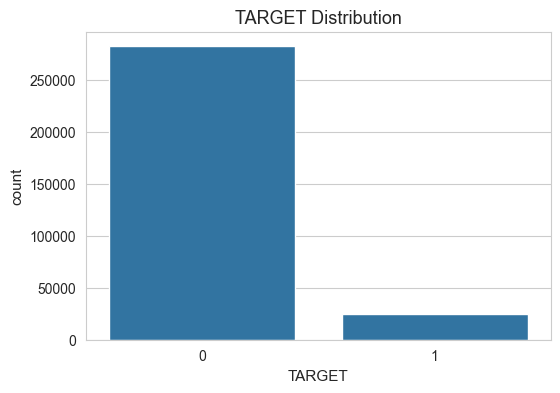

In [57]:
# Target distribution check
display(Markdown("### 5.5 Target Distribution"))

if TARGET_COL in train_df.columns:
    target_counts = train_df[TARGET_COL].value_counts(dropna=False)
    target_pct = (train_df[TARGET_COL].value_counts(normalize=True, dropna=False) * 100).round(2)

    print(target_counts)
    print("\nTarget percentage distribution:")
    print(target_pct)

    plt.figure(figsize=(6, 4))
    sns.countplot(data=train_df, x=TARGET_COL)
    plt.title(f"{TARGET_COL} Distribution")
    plt.show()
else:
    print(f"Target column '{TARGET_COL}' not found in train dataset.")

In [58]:
# Duplicate and column alignment checks
display(Markdown("### 5.6 Duplicate and Alignment Checks"))

train_duplicates = train_df.duplicated().sum()
test_duplicates = test_df.duplicated().sum()

print("Duplicate rows in train:", train_duplicates)
print("Duplicate rows in test :", test_duplicates)
print(f"ID column '{ID_COL}' in train:", ID_COL in train_df.columns)
print(f"ID column '{ID_COL}' in test :", ID_COL in test_df.columns)

train_cols = set(train_df.columns)
test_cols = set(test_df.columns)

only_in_train = sorted(list(train_cols - test_cols))
only_in_test = sorted(list(test_cols - train_cols))
common_cols = sorted(list(train_cols.intersection(test_cols)))

print("\nColumns only in train:", len(only_in_train))
print("Columns only in test :", len(only_in_test))
print("Common columns       :", len(common_cols))

display(pd.DataFrame({"only_in_train": pd.Series(only_in_train)}).head(10))
display(pd.DataFrame({"only_in_test": pd.Series(only_in_test)}).head(10))

### 5.6 Duplicate and Alignment Checks

Duplicate rows in train: 0
Duplicate rows in test : 0
ID column 'SK_ID_CURR' in train: True
ID column 'SK_ID_CURR' in test : True

Columns only in train: 1
Columns only in test : 0
Common columns       : 583


,only_in_train
0,TARGET


,only_in_test


In [59]:
# Build numeric and categorical column lists
numeric_cols = train_df.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
categorical_cols = train_df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

if TARGET_COL in numeric_cols:
    numeric_cols.remove(TARGET_COL)

if ID_COL in numeric_cols:
    numeric_cols.remove(ID_COL)

if ID_COL in categorical_cols:
    categorical_cols.remove(ID_COL)

continuous_numeric_cols, discrete_numeric_cols = split_numeric_columns(train_df, numeric_cols)

dtype_summary = train_df.dtypes.astype(str).value_counts().reset_index()
dtype_summary.columns = ["dtype", "count"]

display(Markdown("### 5.7 Data Type Summary"))
display(dtype_summary)

print("Numeric columns     :", len(numeric_cols))
print("Categorical columns :", len(categorical_cols))
print("Continuous numeric  :", len(continuous_numeric_cols))
print("Discrete numeric    :", len(discrete_numeric_cols))

### 5.7 Data Type Summary

,dtype,count
0,float64,523
1,int64,45
2,object,16


Numeric columns     : 566
Categorical columns : 16
Continuous numeric  : 475
Discrete numeric    : 91


## 6. Structural Audit Recap

In [60]:
display(Markdown("### 6.1 Structural Audit Report - Column Names"))
display(report_df.columns.to_frame(name="report_columns").head(50))

### 6.1 Structural Audit Report - Column Names

,report_columns
Unnamed: 0,Unnamed: 0
column,column
dtype,dtype
non_null_count_x,non_null_count_x
unique_count,unique_count
unique_percentage,unique_percentage
duplicate_count,duplicate_count
duplicate_value_ratio,duplicate_value_ratio
constant_flag,constant_flag
top_value_percentage,top_value_percentage


In [61]:
display(Markdown("### 6.2 Report-Based Quick Summary"))

report_column_name = get_report_column(report_df, ["column"])
report_missing_pct = get_report_column(report_df, ["missing_percentage", "missing_pct", "missing_rate"])
report_zero_ratio = get_report_column(report_df, ["zero_ratio"])
report_skew_label = get_report_column(report_df, ["skew_label"])
report_target_gap = get_report_column(report_df, ["target_rate_gap_abs"])
report_dtype = get_report_column(report_df, ["datatype_current_dtype_report", "dtype"])
report_semantic = get_report_column(report_df, ["semantic_semantic_type_guess", "semantic_current_dtype_report"])
report_recommendation = get_report_column(report_df, ["recommended_action"])
report_high_card = get_report_column(report_df, ["high_cardinality_flag", "high_cardinality"])
report_has_outliers = get_report_column(report_df, ["has_outliers"])

summary_candidates = [
    report_column_name, report_dtype, report_semantic, report_missing_pct,
    report_zero_ratio, report_skew_label, report_target_gap,
    report_high_card, report_has_outliers, report_recommendation
]
summary_candidates = [c for c in summary_candidates if c is not None]

display(report_df[summary_candidates].head(20))

### 6.2 Report-Based Quick Summary

,column,dtype,missing_percentage,zero_ratio,skew_label,high_cardinality_flag,has_outliers,recommended_action
0,AMT_ANNUITY,float64,NaN,0.0000,highly_skewed,True,True,treat_as_categorical
1,AMT_CREDIT,float64,NaN,0.0000,highly_skewed,True,True,treat_as_categorical
2,AMT_GOODS_PRICE,float64,NaN,0.0000,highly_skewed,True,True,drop_or_encode
3,AMT_INCOME_TOTAL,float64,NaN,0.0000,highly_skewed,True,True,drop_or_encode
4,AMT_REQ_CREDIT_BUREAU_DAY,float64,NaN,0.9944,highly_skewed,False,True,drop_or_encode
5,AMT_REQ_CREDIT_BUREAU_HOUR,float64,NaN,0.9939,highly_skewed,False,True,drop_or_encode
6,AMT_REQ_CREDIT_BUREAU_MON,float64,NaN,0.8355,highly_skewed,False,True,drop_or_encode
7,AMT_REQ_CREDIT_BUREAU_QRT,float64,NaN,0.8099,highly_skewed,False,True,drop_or_encode
8,AMT_REQ_CREDIT_BUREAU_WEEK,float64,NaN,0.9679,highly_skewed,False,True,drop_or_encode
9,AMT_REQ_CREDIT_BUREAU_YEAR,float64,NaN,0.2699,highly_skewed,False,True,drop_or_encode


In [62]:
display(Markdown("### 6.3 Top Missing Features from Structural Audit"))

if report_column_name and report_missing_pct:
    top_report_missing = (
        report_df[[report_column_name, report_missing_pct]]
        .sort_values(report_missing_pct, ascending=False)
        .head(20)
        .reset_index(drop=True)
    )
    display(top_report_missing)
else:
    print("Missing-percentage columns not found in report.")

### 6.3 Top Missing Features from Structural Audit

,column,missing_percentage
0,FONDKAPREMONT_MODE,68.3900
1,WALLSMATERIAL_MODE,50.8400
2,HOUSETYPE_MODE,50.1800
3,EMERGENCYSTATE_MODE,47.4000
4,OCCUPATION_TYPE,31.3500
5,NAME_TYPE_SUITE,0.4200
6,FLAG_OWN_REALTY,0.0000
7,CODE_GENDER,0.0000
8,NAME_EDUCATION_TYPE,0.0000
9,NAME_CONTRACT_TYPE,0.0000


In [63]:
display(Markdown("### 6.4 Top Report Features by Target Gap"))

if report_column_name and report_target_gap:
    top_report_signal = (
        report_df[[report_column_name, report_target_gap]]
        .dropna()
        .sort_values(report_target_gap, ascending=False)
        .head(20)
        .reset_index(drop=True)
    )
    display(top_report_signal)
else:
    print("Target gap column not found in report.")

### 6.4 Top Report Features by Target Gap

Target gap column not found in report.


## 7. Feature Grouping

In [64]:
# Manual feature groups based on project knowledge and structural audit review
application_features = existing_cols(train_df, [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "DAYS_LAST_PHONE_CHANGE",
    "DAYS_ID_PUBLISH",
    "DAYS_REGISTRATION"
])

ratio_features = existing_cols(train_df, [
    "APP_ANNUITY_INCOME_RATIO",
    "APP_CREDIT_INCOME_RATIO",
    "APP_CREDIT_ANNUITY_RATIO",
    "APP_INCOME_PER_PERSON",
    "APP_EMPLOYED_BIRTH_RATIO",
    "APP_PHONE_BIRTH_RATIO",
    "APP_PHONE_EMPLOYED_RATIO",
    "APP_CAR_BIRTH_RATIO",
    "APP_EXT_SOURCE_STD"
])

social_features = existing_cols(train_df, [
    "DEF_30_CNT_SOCIAL_CIRCLE",
    "DEF_60_CNT_SOCIAL_CIRCLE",
    "OBS_30_CNT_SOCIAL_CIRCLE",
    "OBS_60_CNT_SOCIAL_CIRCLE",
    "AMT_REQ_CREDIT_BUREAU_DAY",
    "AMT_REQ_CREDIT_BUREAU_HOUR",
    "AMT_REQ_CREDIT_BUREAU_WEEK",
    "AMT_REQ_CREDIT_BUREAU_MON",
    "AMT_REQ_CREDIT_BUREAU_QRT",
    "AMT_REQ_CREDIT_BUREAU_YEAR"
])

categorical_features = existing_cols(train_df, [
    "CODE_GENDER",
    "NAME_CONTRACT_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
    "NAME_INCOME_TYPE",
    "NAME_TYPE_SUITE",
    "OCCUPATION_TYPE",
    "ORGANIZATION_TYPE",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    "WEEKDAY_APPR_PROCESS_START",
    "HOUSETYPE_MODE",
    "WALLSMATERIAL_MODE",
    "EMERGENCYSTATE_MODE",
    "FONDKAPREMONT_MODE"
])

housing_features = existing_cols(train_df, [
    "TOTALAREA_MODE",
    "APARTMENTS_AVG", "APARTMENTS_MEDI", "APARTMENTS_MODE",
    "LIVINGAREA_AVG", "LIVINGAREA_MEDI", "LIVINGAREA_MODE",
    "NONLIVINGAREA_AVG", "NONLIVINGAREA_MEDI", "NONLIVINGAREA_MODE",
    "BASEMENTAREA_AVG", "BASEMENTAREA_MEDI", "BASEMENTAREA_MODE",
    "ENTRANCES_AVG", "ENTRANCES_MEDI", "ENTRANCES_MODE",
    "ELEVATORS_AVG", "ELEVATORS_MEDI", "ELEVATORS_MODE",
    "FLOORSMAX_AVG", "FLOORSMAX_MEDI", "FLOORSMAX_MODE",
    "YEARS_BEGINEXPLUATATION_AVG", "YEARS_BEGINEXPLUATATION_MEDI", "YEARS_BEGINEXPLUATATION_MODE",
    "YEARS_BUILD_AVG", "YEARS_BUILD_MEDI", "YEARS_BUILD_MODE"
])

history_features = [col for col in train_df.columns if col.startswith((
    "BUREAU_", "PREV_", "REFUSED_", "APPROVED_", "INS_", "CC_", "POS_"
))]

In [65]:
group_summary = pd.DataFrame({
    "feature_group": [
        "application_features",
        "ratio_features",
        "social_features",
        "categorical_features",
        "housing_features",
        "history_features"
    ],
    "count": [
        len(application_features),
        len(ratio_features),
        len(social_features),
        len(categorical_features),
        len(housing_features),
        len(history_features)
    ]
})

display(group_summary)

,feature_group,count
0,application_features,11
1,ratio_features,9
2,social_features,10
3,categorical_features,16
4,housing_features,28
5,history_features,443


In [66]:
display(Markdown("### 7.1 Feature Group Previews"))
print("Application features:\n", application_features)
print("\nRatio features:\n", ratio_features)
print("\nSocial features:\n", social_features)
print("\nCategorical features:\n", categorical_features)
print("\nHousing features:\n", housing_features[:20], "..." if len(housing_features) > 20 else "")
print("\nHistory features count:", len(history_features))

### 7.1 Feature Group Previews

Application features:
 ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_LAST_PHONE_CHANGE', 'DAYS_ID_PUBLISH', 'DAYS_REGISTRATION']

Ratio features:
 ['APP_ANNUITY_INCOME_RATIO', 'APP_CREDIT_INCOME_RATIO', 'APP_CREDIT_ANNUITY_RATIO', 'APP_INCOME_PER_PERSON', 'APP_EMPLOYED_BIRTH_RATIO', 'APP_PHONE_BIRTH_RATIO', 'APP_PHONE_EMPLOYED_RATIO', 'APP_CAR_BIRTH_RATIO', 'APP_EXT_SOURCE_STD']

Social features:
 ['DEF_30_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'OBS_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR']

Categorical features:
 ['CODE_GENDER', 'NAME_CONTRACT_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'NAME_INCOME_TYPE', 'NAME_TYPE_SUITE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE', 'FLAG_O

### 7.2 Feature Group Size Overview

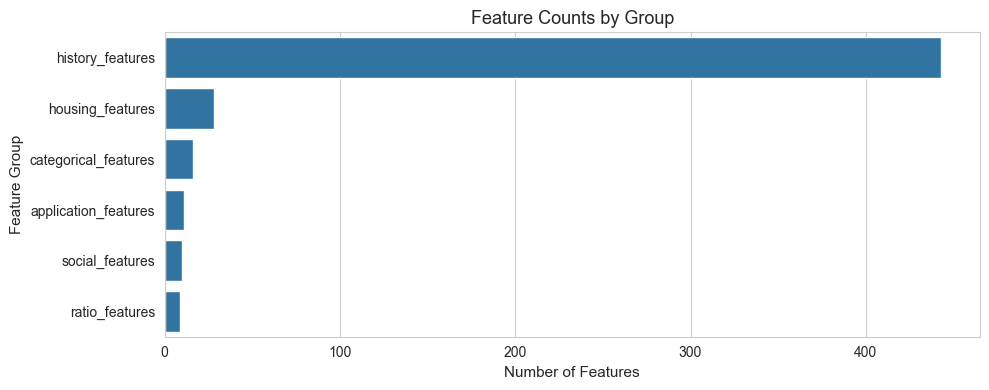

In [67]:
display(Markdown("### 7.2 Feature Group Size Overview"))

plt.figure(figsize=(10, 4))
sns.barplot(data=group_summary.sort_values("count", ascending=False), x="count", y="feature_group")
plt.title("Feature Counts by Group")
plt.xlabel("Number of Features")
plt.ylabel("Feature Group")
plt.tight_layout()
plt.show()


## 8. Important Feature Shortlist for Focused EDA

In [68]:
# Shortlisted important features for practical EDA
important_numeric_features = existing_cols(train_df, [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "APP_ANNUITY_INCOME_RATIO",
    "APP_CREDIT_INCOME_RATIO",
    "APP_CREDIT_ANNUITY_RATIO",
    "APP_INCOME_PER_PERSON",
    "APP_PHONE_BIRTH_RATIO",
    "APP_EMPLOYED_BIRTH_RATIO",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "DAYS_LAST_PHONE_CHANGE",
    "DEF_30_CNT_SOCIAL_CIRCLE",
    "DEF_60_CNT_SOCIAL_CIRCLE",
    "OBS_30_CNT_SOCIAL_CIRCLE",
    "OBS_60_CNT_SOCIAL_CIRCLE",
    "AMT_REQ_CREDIT_BUREAU_YEAR",
    "TOTALAREA_MODE",
    "APARTMENTS_AVG",
    "LIVINGAREA_AVG",
    "BUREAU_CLOSED_AMT_CREDIT_SUM_MEAN",
    "REFUSED_AMT_APPLICATION_MEAN",
    "PREV_CREDIT_TO_ANNUITY_RATIO_MEAN",
    "INS_PAY_PERC_MEAN"
])

important_categorical_features = existing_cols(train_df, [
    "NAME_CONTRACT_TYPE",
    "CODE_GENDER",
    "NAME_EDUCATION_TYPE",
    "NAME_INCOME_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
    "NAME_TYPE_SUITE",
    "OCCUPATION_TYPE",
    "ORGANIZATION_TYPE"
])

important_continuous_features = [col for col in important_numeric_features if col in continuous_numeric_cols]
important_discrete_features = [col for col in important_numeric_features if col in discrete_numeric_cols]

display(Markdown("### 8.1 Selected Important Features"))
print("Important continuous features:\n", important_continuous_features)
print("\nImportant discrete features:\n", important_discrete_features)
print("\nImportant categorical features:\n", important_categorical_features)

### 8.1 Selected Important Features

Important continuous features:
 ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'APP_ANNUITY_INCOME_RATIO', 'APP_CREDIT_INCOME_RATIO', 'APP_CREDIT_ANNUITY_RATIO', 'APP_INCOME_PER_PERSON', 'APP_PHONE_BIRTH_RATIO', 'APP_EMPLOYED_BIRTH_RATIO', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_LAST_PHONE_CHANGE', 'OBS_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'TOTALAREA_MODE', 'APARTMENTS_AVG', 'LIVINGAREA_AVG', 'BUREAU_CLOSED_AMT_CREDIT_SUM_MEAN', 'REFUSED_AMT_APPLICATION_MEAN', 'PREV_CREDIT_TO_ANNUITY_RATIO_MEAN', 'INS_PAY_PERC_MEAN']

Important discrete features:
 ['DEF_30_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE']

Important categorical features:
 ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'NAME_EDUCATION_TYPE', 'NAME_INCOME_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'NAME_TYPE_SUITE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE']


In [69]:
display(Markdown("### 8.2 Optional Report-Based Signal Features"))

if report_column_name and report_target_gap:
    report_signal_features = (
        report_df[[report_column_name, report_target_gap]]
        .dropna()
        .sort_values(report_target_gap, ascending=False)
        .head(30)[report_column_name]
        .tolist()
    )
    report_signal_features = [col for col in report_signal_features if col in train_df.columns]
    print("Top report-based signal features found in train:")
    print(report_signal_features[:20])
else:
    report_signal_features = []
    print("Report-based signal ranking not available.")

### 8.2 Optional Report-Based Signal Features

Report-based signal ranking not available.


## 9. Missing Value Analysis

,column,missing_count,missing_pct
0,CC_PAYMENT_MIN_RATIO_MAX,248242,80.7262
1,CC_PAYMENT_MIN_RATIO_MEAN,248242,80.7262
2,CC_PAYMENT_TOTAL_RATIO_MAX,247736,80.5617
3,CC_PAYMENT_TOTAL_RATIO_MEAN,247736,80.5617
4,CC_AMT_PAYMENT_CURRENT_MAX,246451,80.1438
5,CC_AMT_PAYMENT_CURRENT_MEAN,246451,80.1438
6,CC_AMT_DRAWINGS_ATM_CURRENT_MAX,246371,80.1178
7,CC_AMT_DRAWINGS_ATM_CURRENT_MEAN,246371,80.1178
8,CC_AMT_DRAWINGS_POS_CURRENT_MAX,246371,80.1178
9,CC_AMT_DRAWINGS_POS_CURRENT_MEAN,246371,80.1178


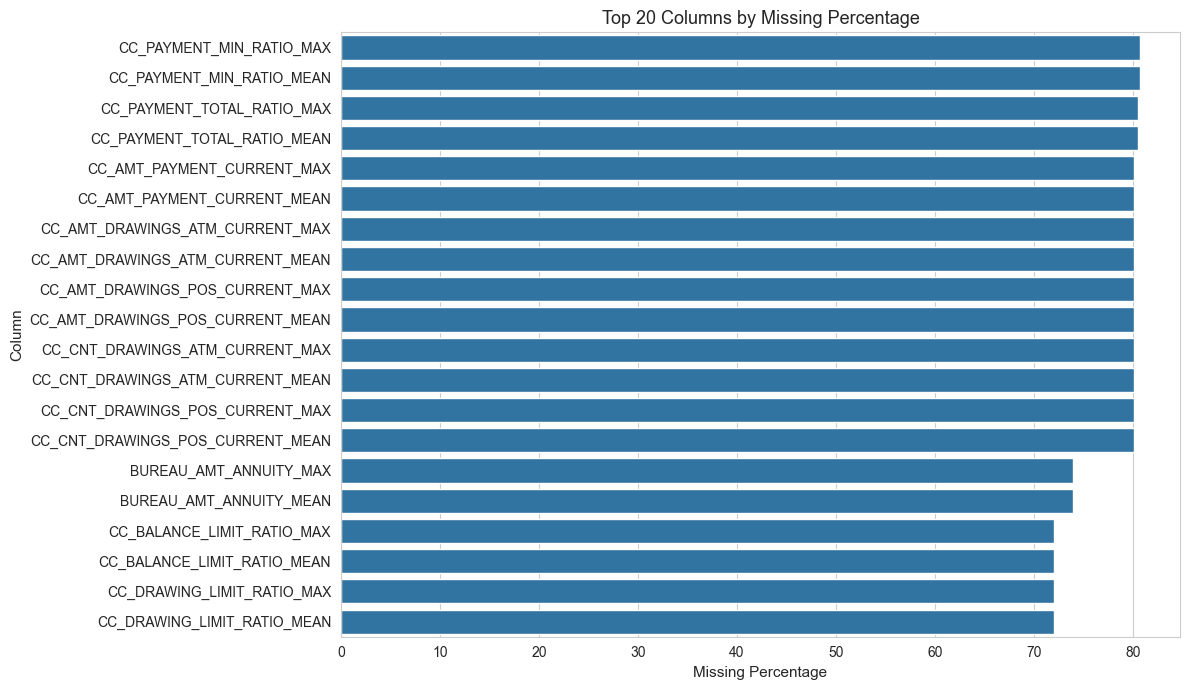

In [70]:
missing_df = build_missing_summary(train_df)
display(missing_df.head(20))
plot_top_missing(missing_df, top_n=20)

In [71]:
display(Markdown("### 9.1 Missing Summary for Important Features"))
important_missing_summary = missing_df[missing_df["column"].isin(important_numeric_features + important_categorical_features)]
display(important_missing_summary.sort_values("missing_pct", ascending=False))

### 9.1 Missing Summary for Important Features

,column,missing_count,missing_pct
105,REFUSED_AMT_APPLICATION_MEAN,207217,67.3852
129,APARTMENTS_AVG,156061,50.7497
135,LIVINGAREA_AVG,154350,50.1933
145,TOTALAREA_MODE,148431,48.2685
153,OCCUPATION_TYPE,96391,31.3455
176,BUREAU_CLOSED_AMT_CREDIT_SUM_MEAN,77346,25.1523
184,DAYS_EMPLOYED,55374,18.0072
185,APP_EMPLOYED_BIRTH_RATIO,55374,18.0072
245,AMT_REQ_CREDIT_BUREAU_YEAR,41519,13.5016
297,PREV_CREDIT_TO_ANNUITY_RATIO_MEAN,16872,5.4866


### 9.2 Missing vs Target Comparison

,column,target_rate_missing,target_rate_non_missing,missing_pct,abs_gap
0,CC_PAYMENT_TOTAL_RATIO_MEAN,0.0759,0.1006,80.5617,0.0247
1,CC_PAYMENT_TOTAL_RATIO_MAX,0.0759,0.1006,80.5617,0.0247
2,CC_PAYMENT_MIN_RATIO_MEAN,0.0760,0.1006,80.7262,0.0246
3,CC_PAYMENT_MIN_RATIO_MAX,0.0760,0.1006,80.7262,0.0246
4,CC_AMT_DRAWINGS_ATM_CURRENT_MEAN,0.0758,0.1004,80.1178,0.0246
5,CC_AMT_DRAWINGS_ATM_CURRENT_MAX,0.0758,0.1004,80.1178,0.0246
6,CC_AMT_DRAWINGS_POS_CURRENT_MAX,0.0758,0.1004,80.1178,0.0246
7,CC_AMT_DRAWINGS_POS_CURRENT_MEAN,0.0758,0.1004,80.1178,0.0246
8,CC_AMT_PAYMENT_CURRENT_MEAN,0.0760,0.1000,80.1438,0.0240
9,CC_AMT_PAYMENT_CURRENT_MAX,0.0760,0.1000,80.1438,0.0240


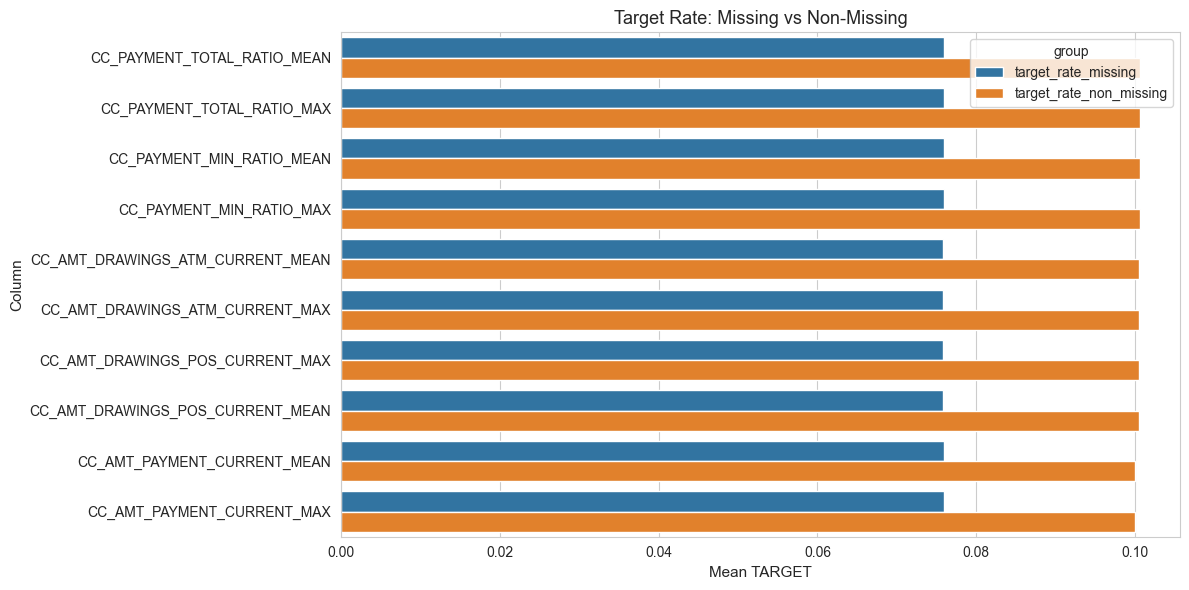

In [72]:
display(Markdown("### 9.2 Missing vs Target Comparison"))

top_missing_feature_list = missing_df[missing_df["missing_pct"] > 0]["column"].tolist()
plot_missing_vs_target(train_df, top_missing_feature_list, TARGET_COL, top_n=10)

### 9.3 Missingness Pattern Heatmap

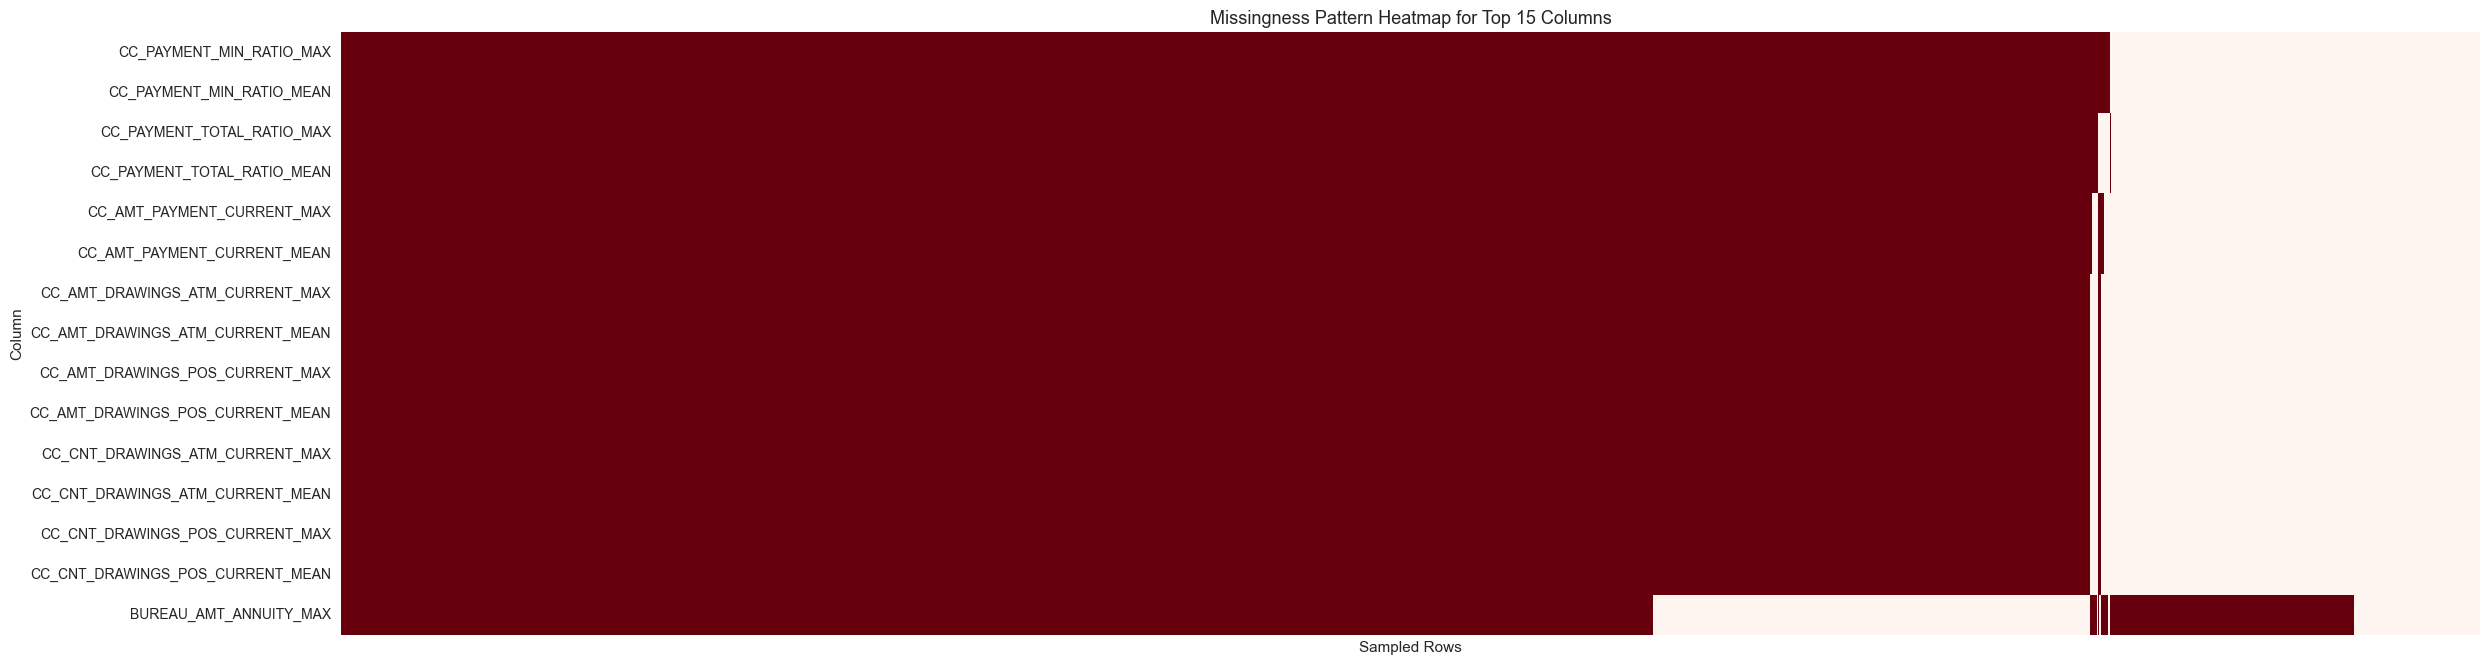

In [73]:
display(Markdown("### 9.3 Missingness Pattern Heatmap"))
plot_missing_pattern_heatmap(train_df, missing_df, top_n=15, sample_size=2500)


## 10. Univariate Analysis

### 10.1 Continuous Numeric Feature Distributions

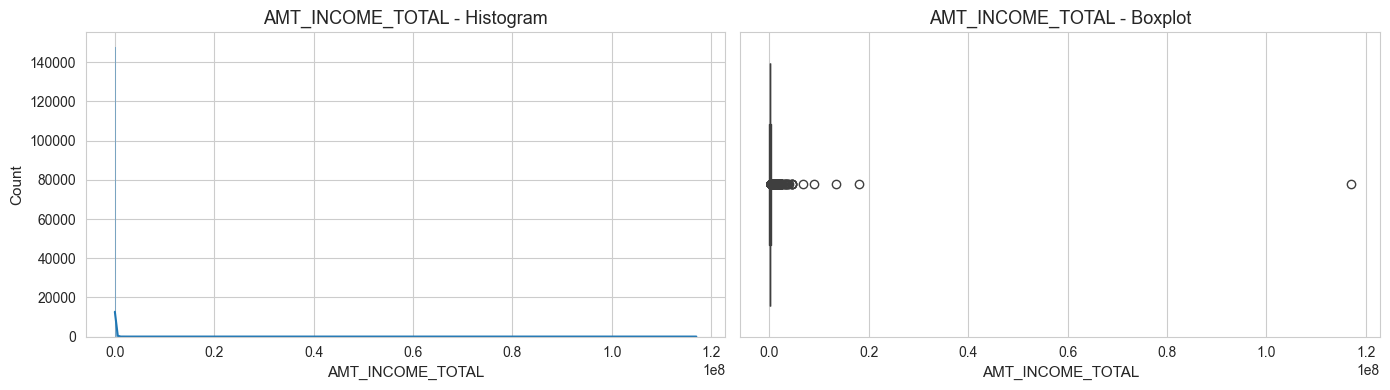

AMT_INCOME_TOTAL | missing%=0.00 | skewness=391.560 | nunique=2548


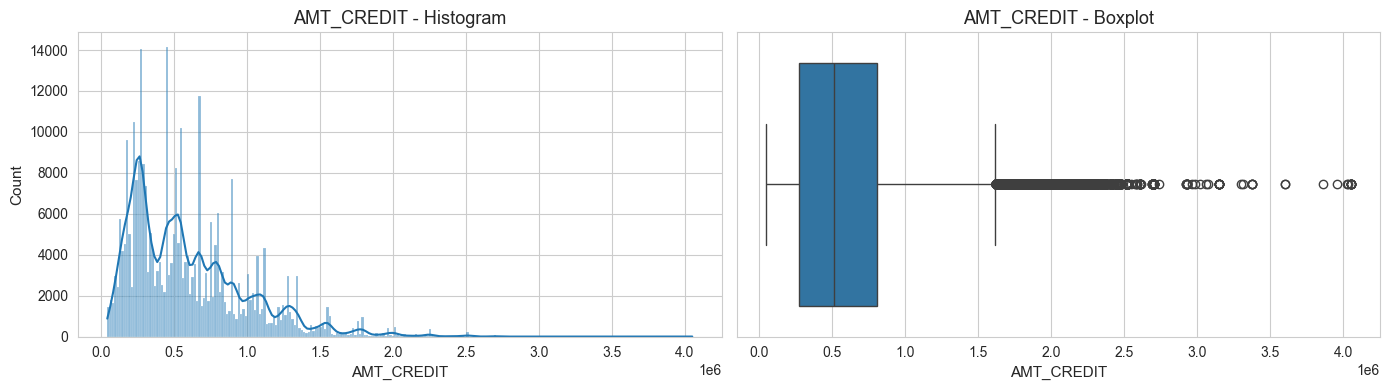

AMT_CREDIT | missing%=0.00 | skewness=1.235 | nunique=5603


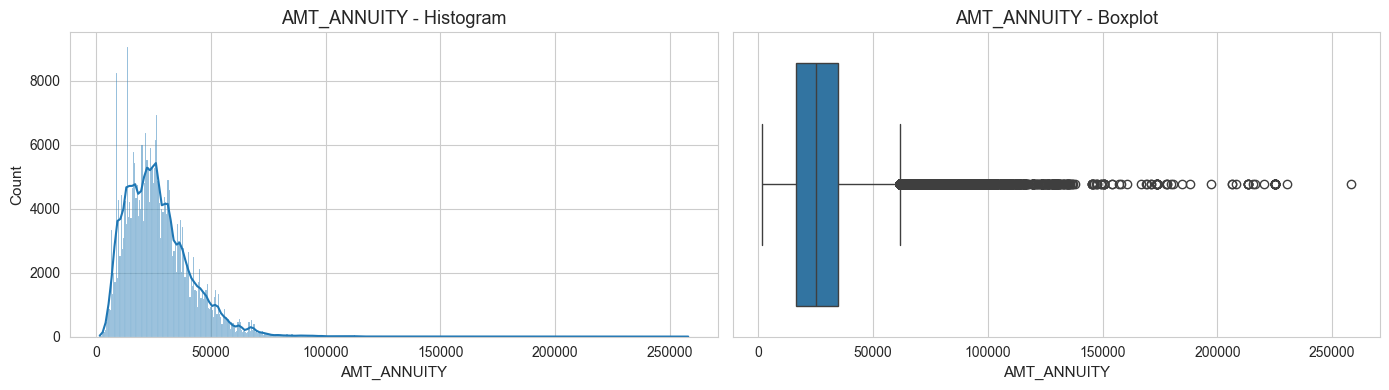

AMT_ANNUITY | missing%=0.00 | skewness=1.580 | nunique=13672


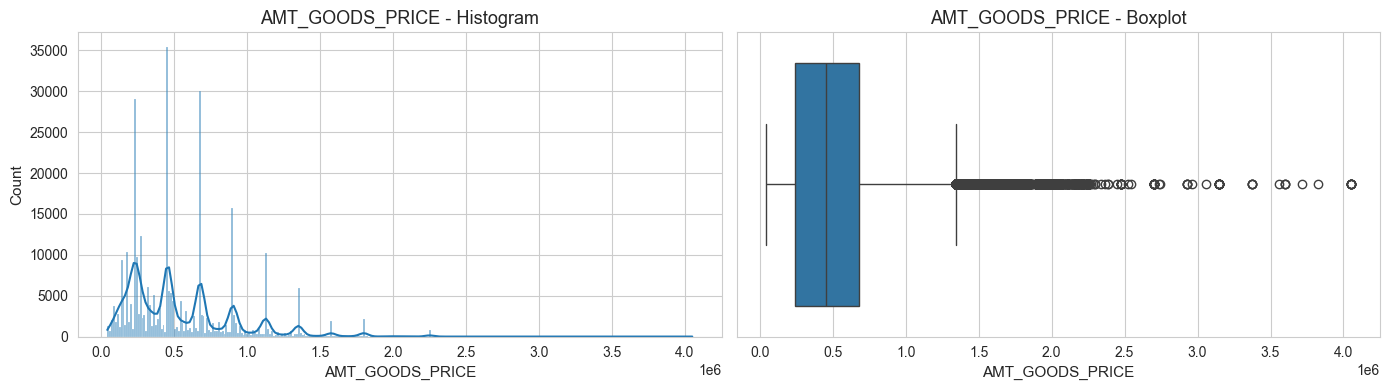

AMT_GOODS_PRICE | missing%=0.09 | skewness=1.349 | nunique=1002


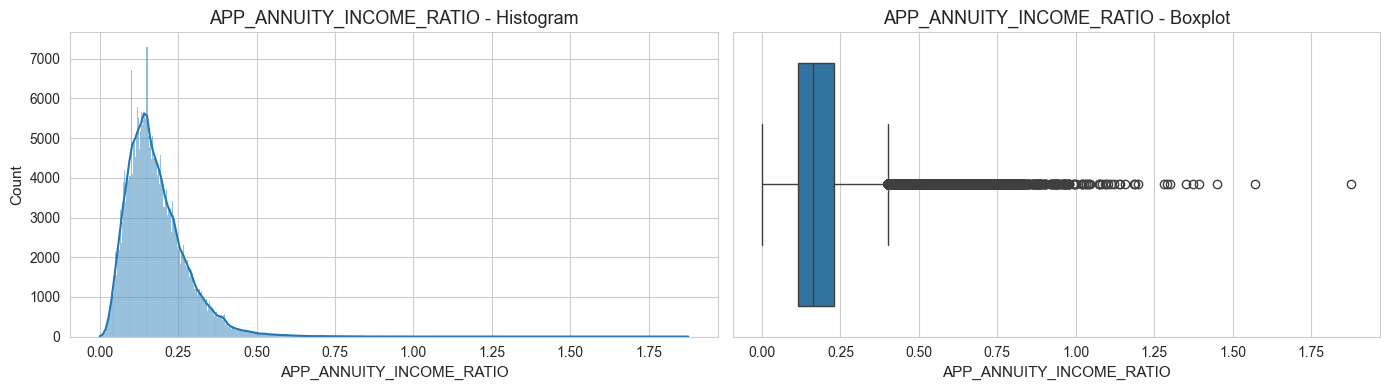

APP_ANNUITY_INCOME_RATIO | missing%=0.00 | skewness=1.512 | nunique=88811


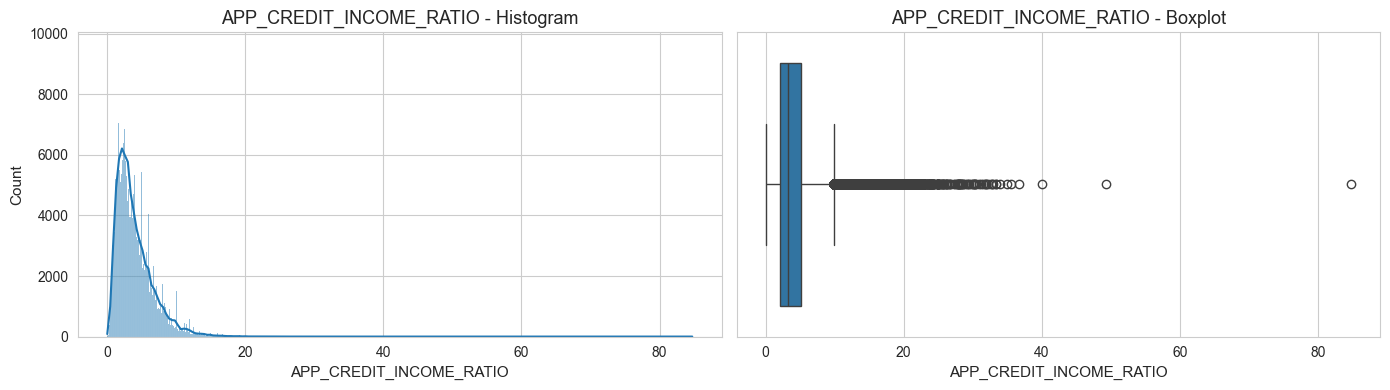

APP_CREDIT_INCOME_RATIO | missing%=0.00 | skewness=1.836 | nunique=48697


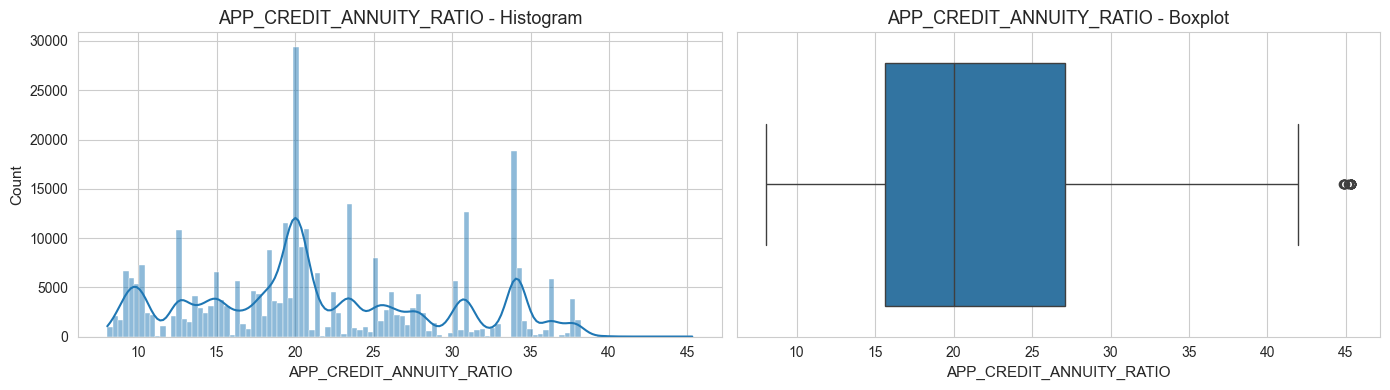

APP_CREDIT_ANNUITY_RATIO | missing%=0.00 | skewness=0.305 | nunique=39539


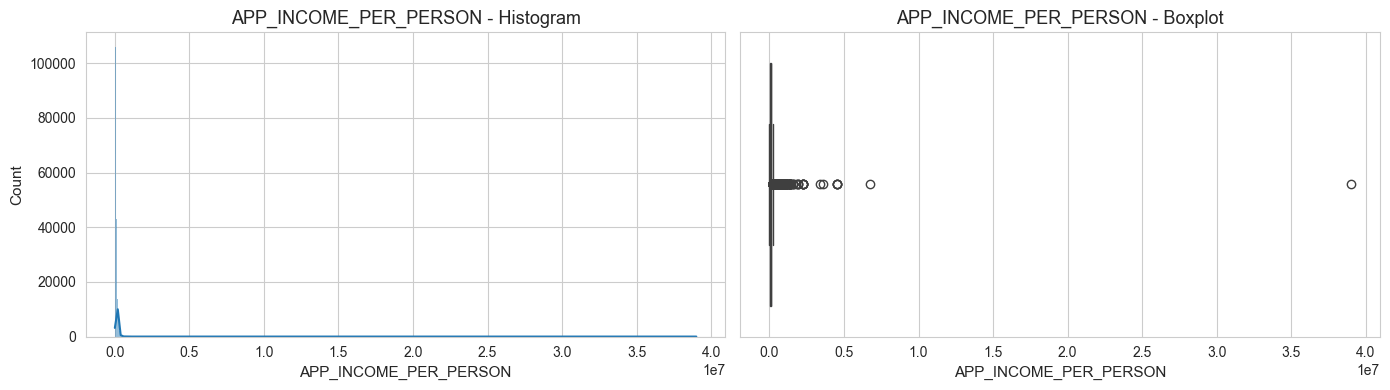

APP_INCOME_PER_PERSON | missing%=0.00 | skewness=187.367 | nunique=3064


In [74]:
display(Markdown("### 10.1 Continuous Numeric Feature Distributions"))

for col in important_continuous_features[:MAX_CONTINUOUS_PLOTS]:
    plot_numeric_distribution(train_df, col)

### 10.2 Discrete Numeric Feature Distributions

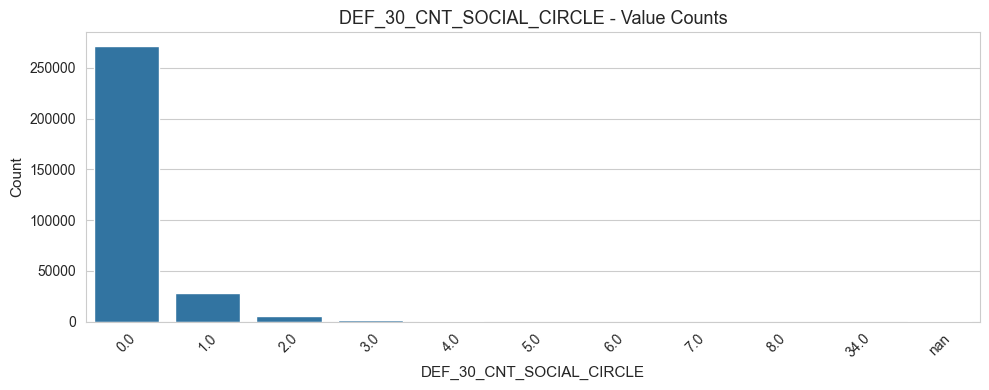

DEF_30_CNT_SOCIAL_CIRCLE | missing%=0.33 | nunique=11


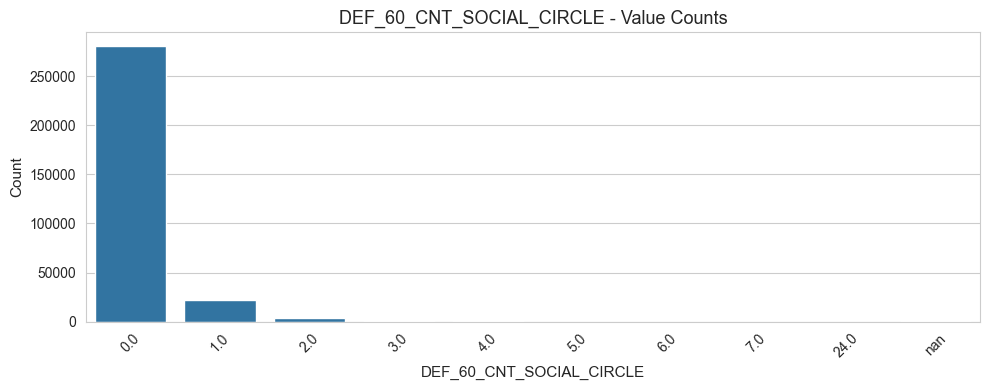

DEF_60_CNT_SOCIAL_CIRCLE | missing%=0.33 | nunique=10


In [75]:
display(Markdown("### 10.2 Discrete Numeric Feature Distributions"))

for col in important_discrete_features[:MAX_DISCRETE_PLOTS]:
    plot_discrete_distribution(train_df, col)

### 10.3 Categorical Feature Distributions

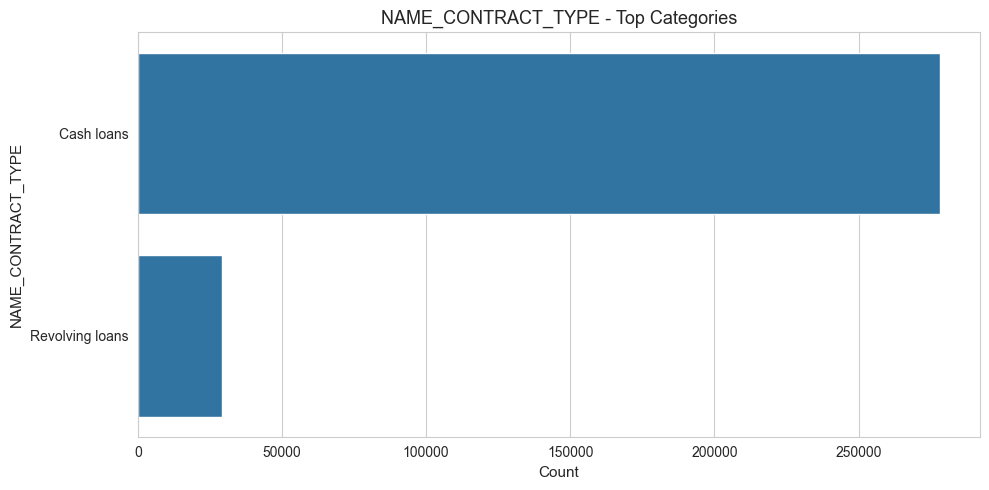

NAME_CONTRACT_TYPE | missing%=0.00 | nunique=2


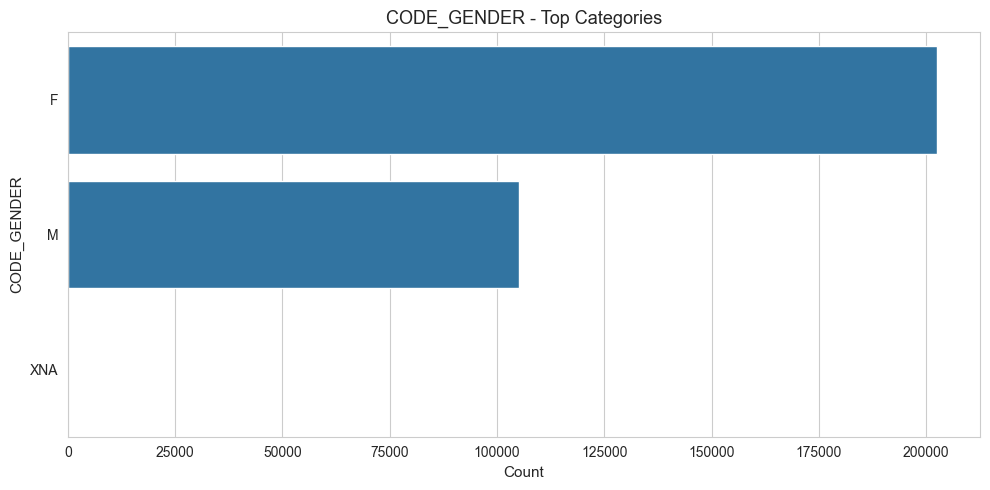

CODE_GENDER | missing%=0.00 | nunique=3


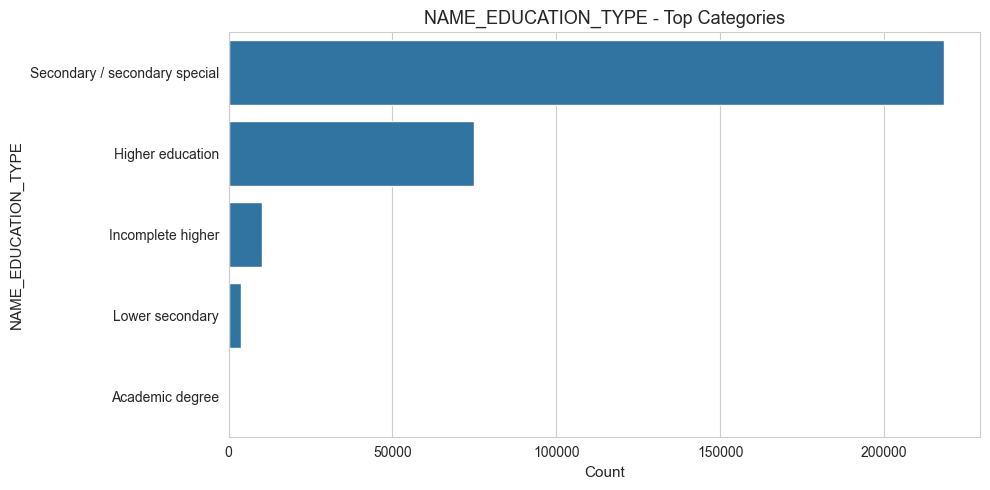

NAME_EDUCATION_TYPE | missing%=0.00 | nunique=5


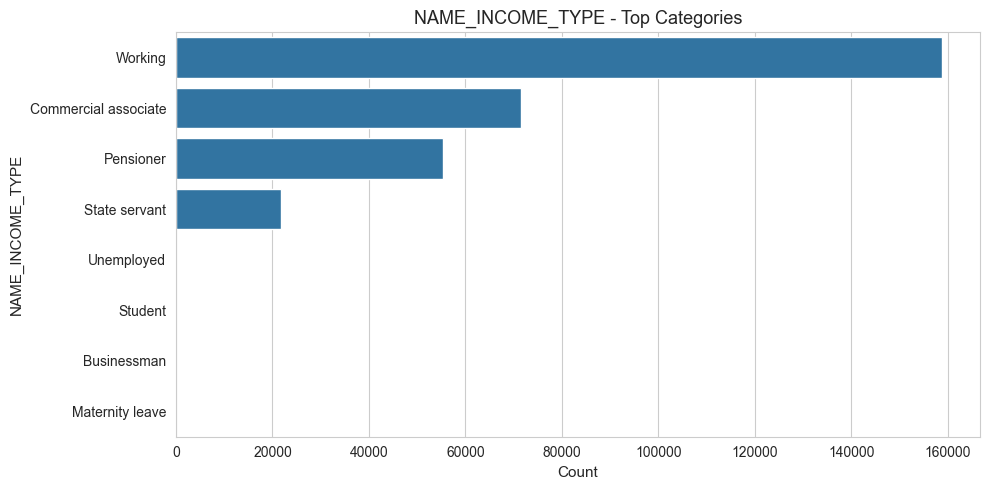

NAME_INCOME_TYPE | missing%=0.00 | nunique=8


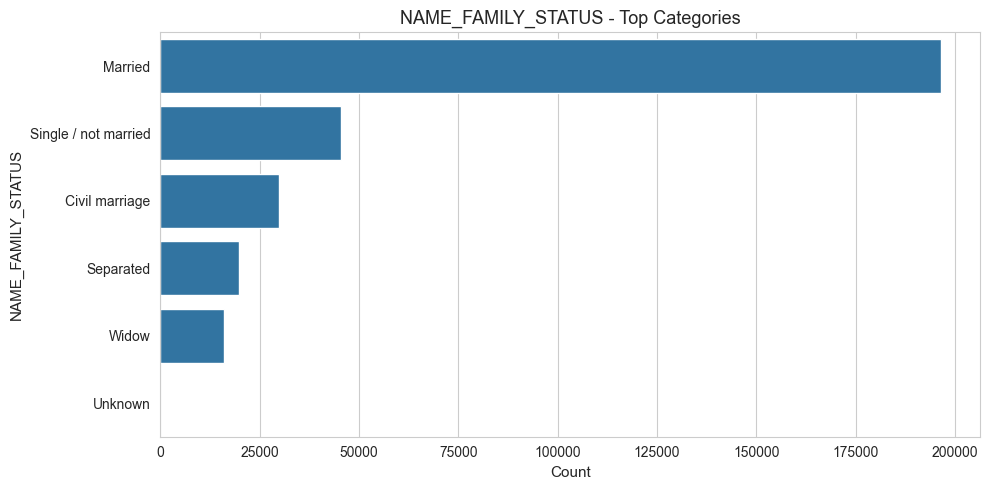

NAME_FAMILY_STATUS | missing%=0.00 | nunique=6


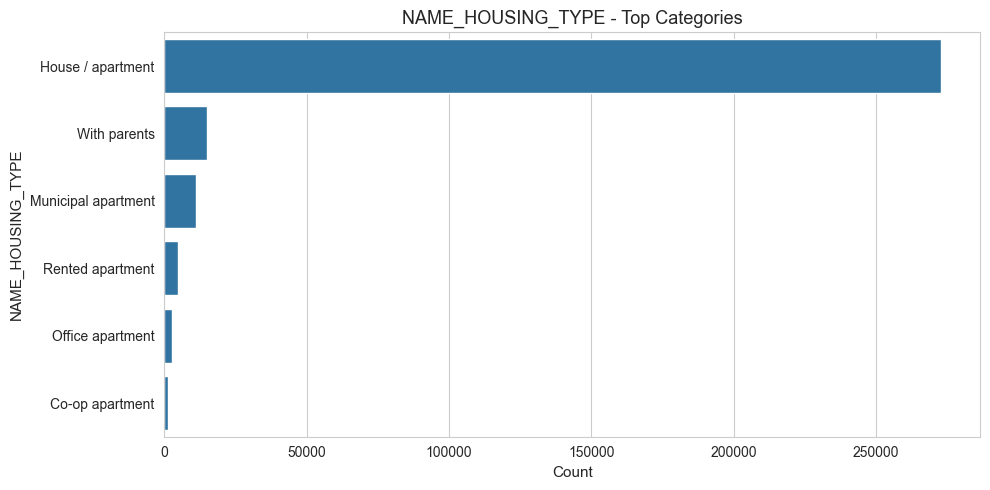

NAME_HOUSING_TYPE | missing%=0.00 | nunique=6


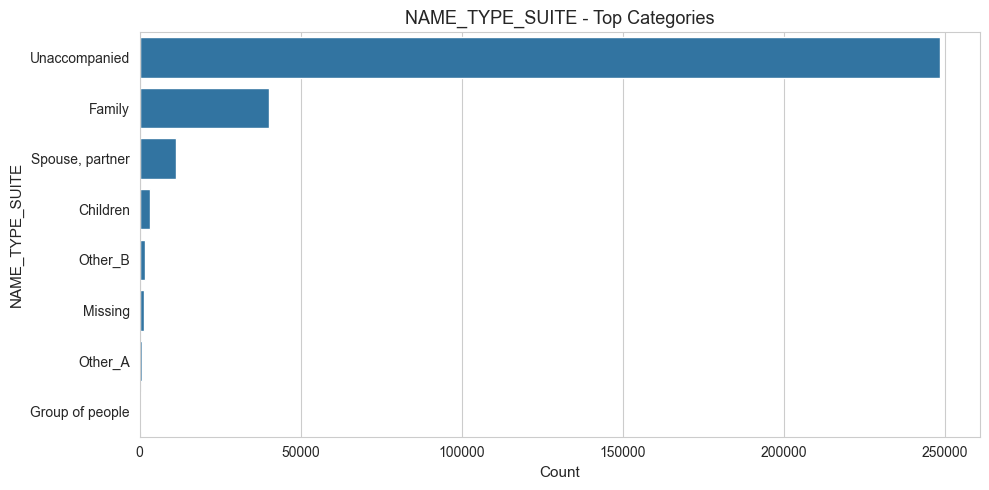

NAME_TYPE_SUITE | missing%=0.42 | nunique=8


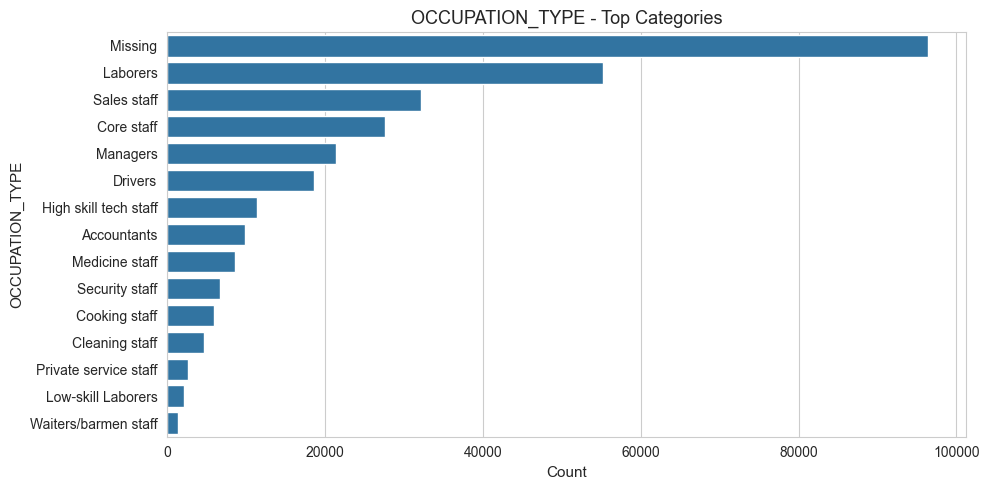

OCCUPATION_TYPE | missing%=31.35 | nunique=19


In [76]:
display(Markdown("### 10.3 Categorical Feature Distributions"))

for col in important_categorical_features[:MAX_CATEGORICAL_PLOTS]:
    plot_categorical_distribution(train_df, col, top_n=15)

In [77]:
display(Markdown("### 10.4 Quick Zero Ratio Summary for Important Numeric Features"))
zero_summary_df = build_zero_summary(train_df, important_numeric_features)
display(zero_summary_df.head(20))

### 10.4 Quick Zero Ratio Summary for Important Numeric Features

,column,zero_pct
0,DEF_60_CNT_SOCIAL_CIRCLE,91.2881
1,DEF_30_CNT_SOCIAL_CIRCLE,88.2323
2,OBS_60_CNT_SOCIAL_CIRCLE,53.5480
3,OBS_30_CNT_SOCIAL_CIRCLE,53.3022
4,AMT_REQ_CREDIT_BUREAU_YEAR,23.3491
5,DAYS_LAST_PHONE_CHANGE,12.2506
6,APP_PHONE_BIRTH_RATIO,12.2506
7,REFUSED_AMT_APPLICATION_MEAN,2.6516
8,BUREAU_CLOSED_AMT_CREDIT_SUM_MEAN,0.6188
9,APARTMENTS_AVG,0.2442


### 10.5 Top Skewed Important Continuous Features

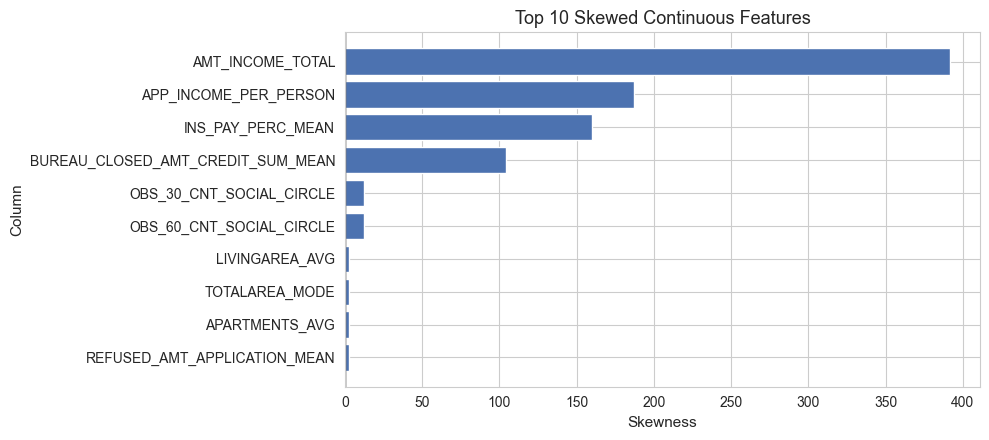

,column,skewness,abs_skew,missing_pct
0,AMT_INCOME_TOTAL,391.5597,391.5597,0.0000
1,APP_INCOME_PER_PERSON,187.3673,187.3673,0.0007
2,INS_PAY_PERC_MEAN,159.9077,159.9077,5.1637
3,BUREAU_CLOSED_AMT_CREDIT_SUM_MEAN,104.2441,104.2441,25.1523
4,OBS_30_CNT_SOCIAL_CIRCLE,12.1396,12.1396,0.3320
5,OBS_60_CNT_SOCIAL_CIRCLE,12.0708,12.0708,0.3320
6,LIVINGAREA_AVG,2.8547,2.8547,50.1933
7,TOTALAREA_MODE,2.7976,2.7976,48.2685
8,APARTMENTS_AVG,2.6418,2.6418,50.7497
9,REFUSED_AMT_APPLICATION_MEAN,2.4506,2.4506,67.3852


In [78]:
display(Markdown("### 10.5 Top Skewed Important Continuous Features"))
plot_top_skewed_features(train_df, important_continuous_features, top_n=10)


### 10.6 Zero-Dominant Important Numeric Features

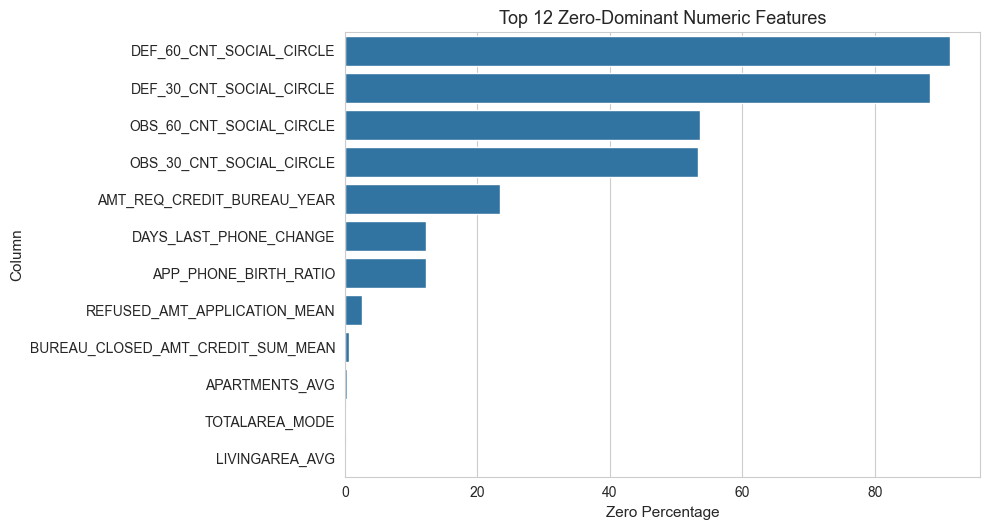

In [79]:
display(Markdown("### 10.6 Zero-Dominant Important Numeric Features"))
plot_zero_ratio_bars(zero_summary_df, top_n=12)


## 11. Bivariate Analysis with Target

### 11.1 Continuous Numeric Features vs Target

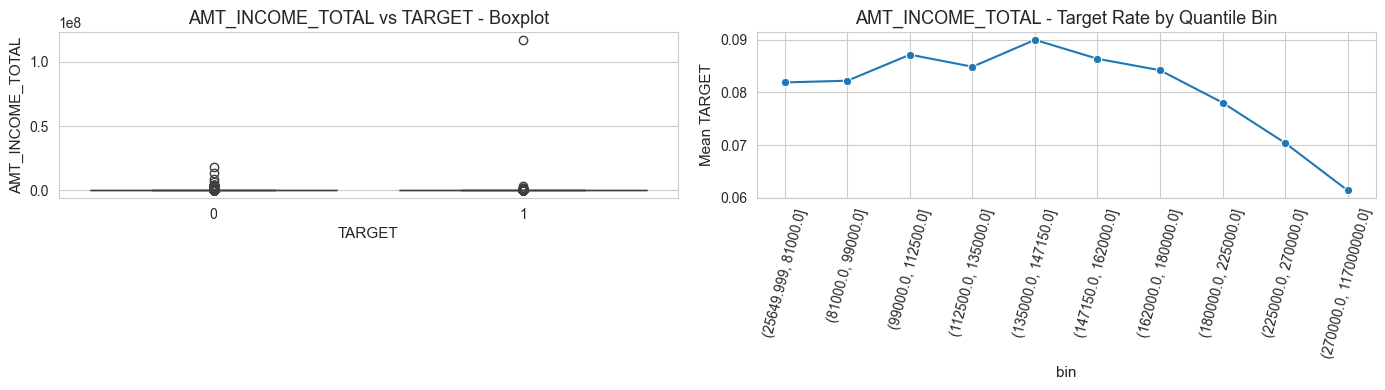

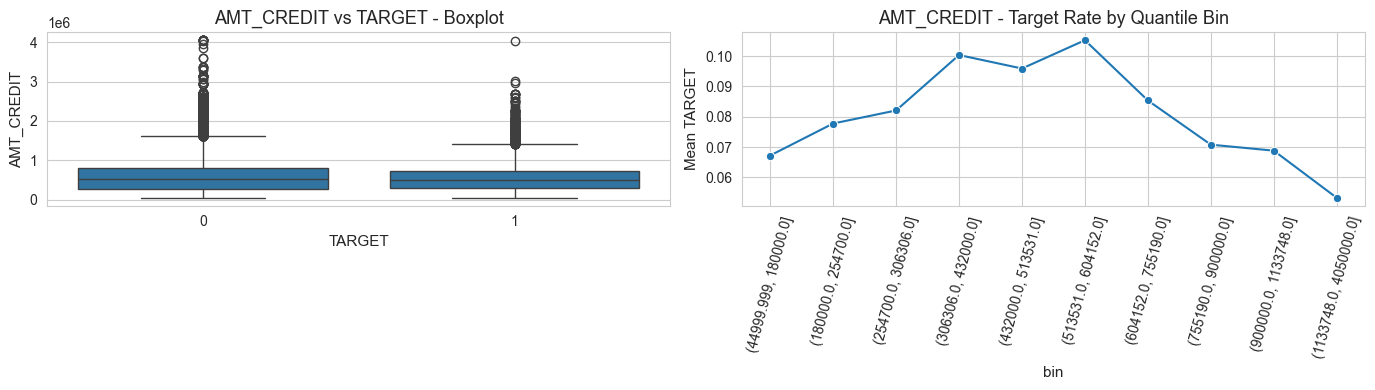

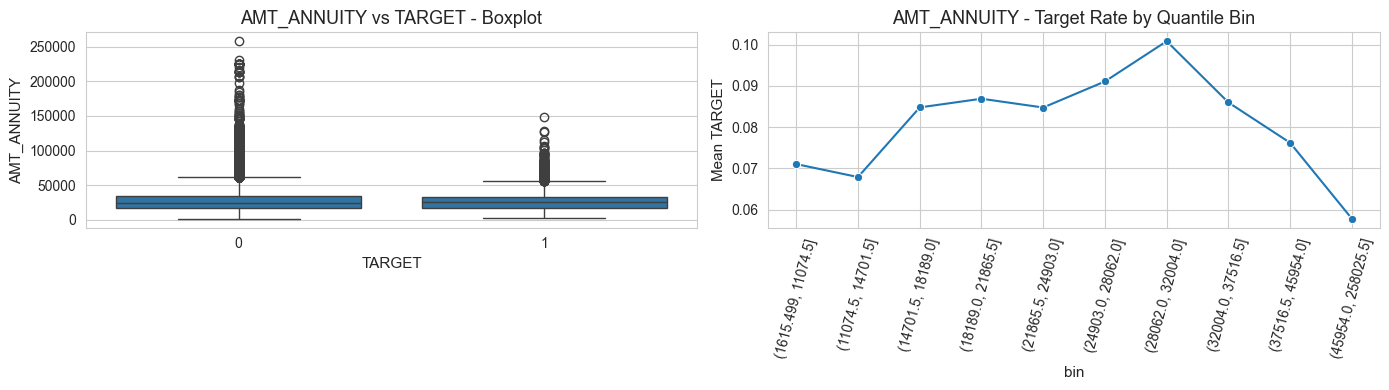

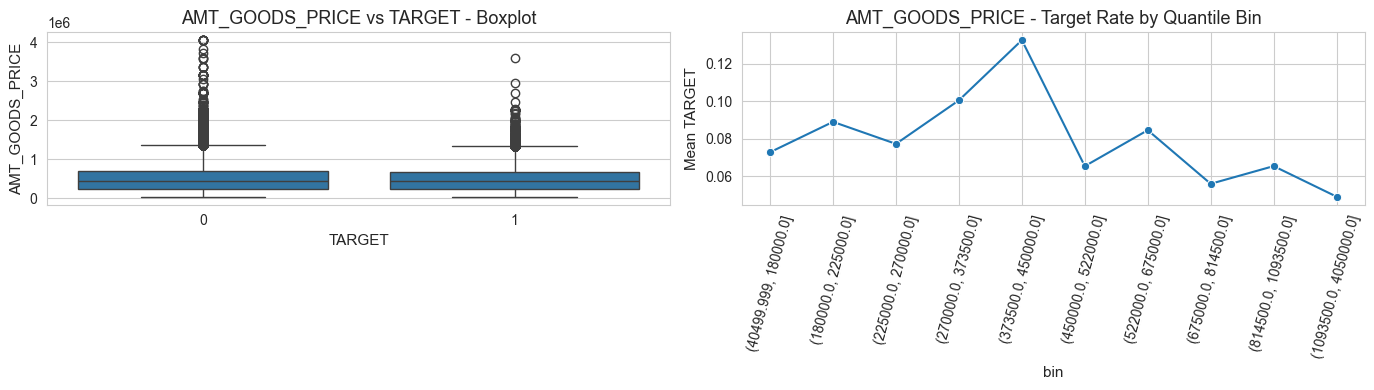

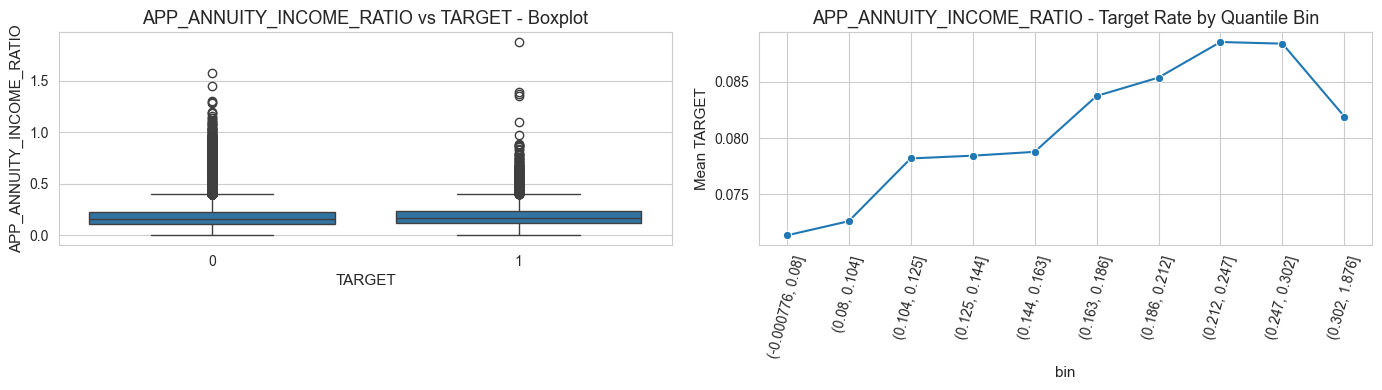

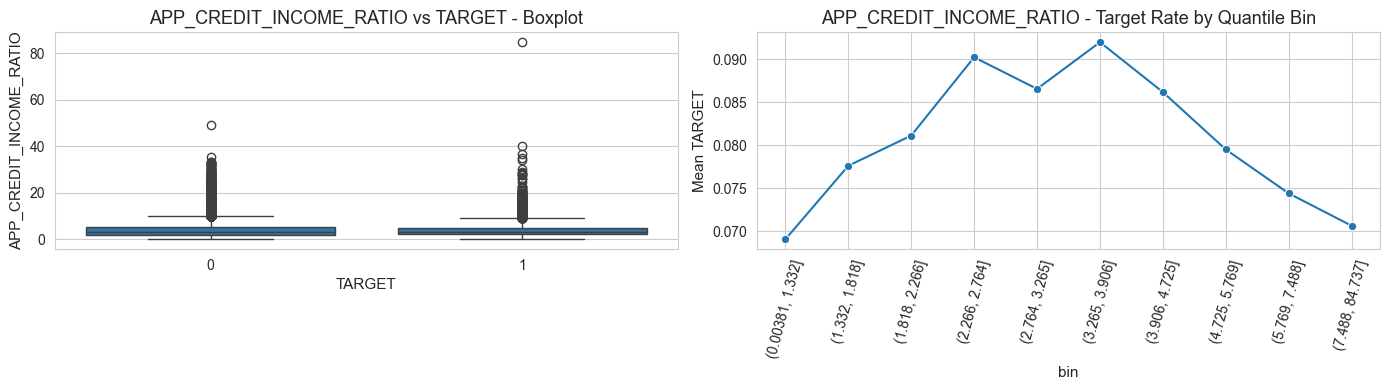

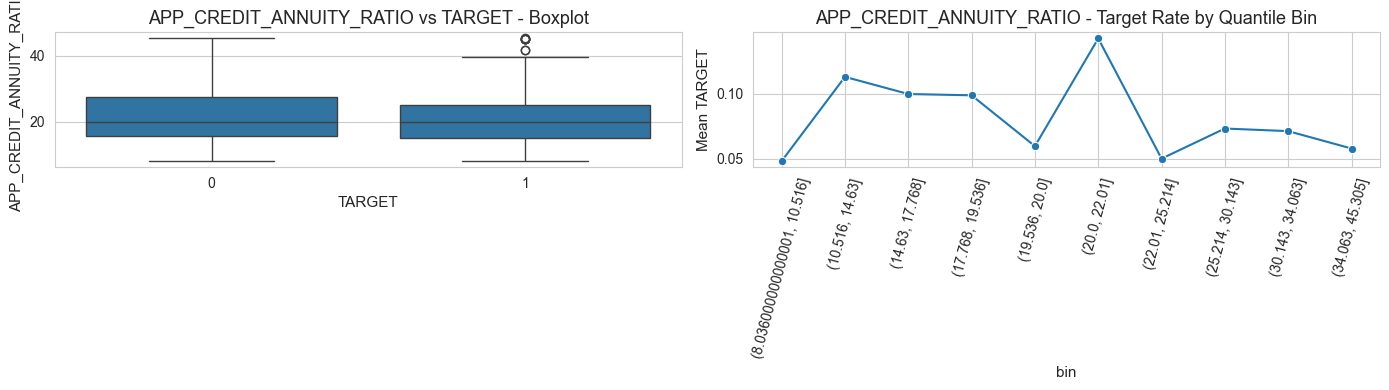

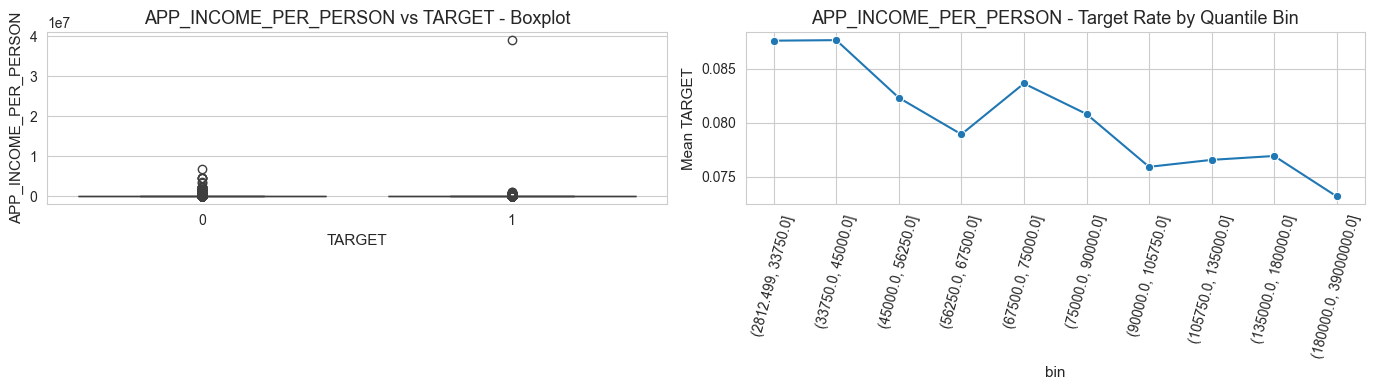

In [80]:
display(Markdown("### 11.1 Continuous Numeric Features vs Target"))

for col in important_continuous_features[:MAX_NUMERIC_TARGET_PLOTS]:
    plot_numeric_vs_target(train_df, col, TARGET_COL, q=10)

### 11.2 Discrete Numeric Features vs Target

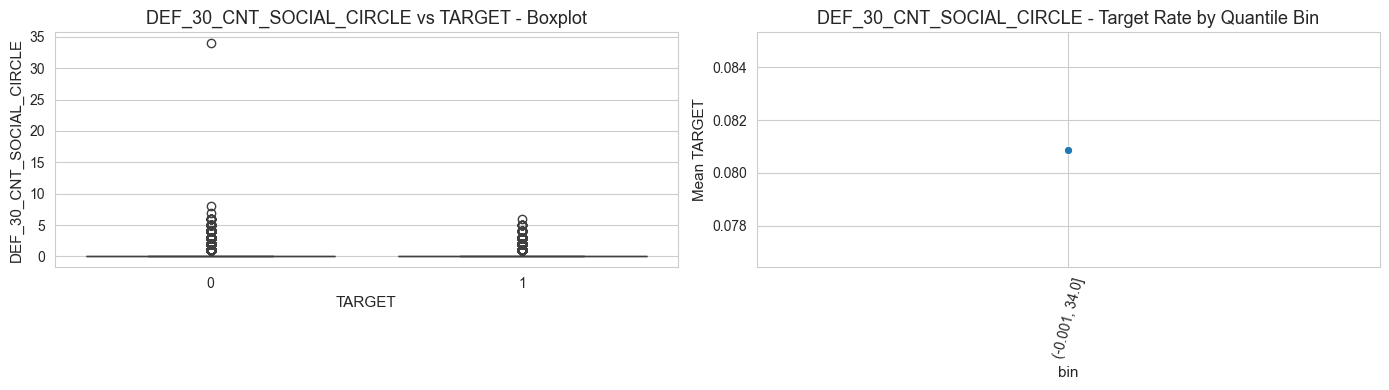

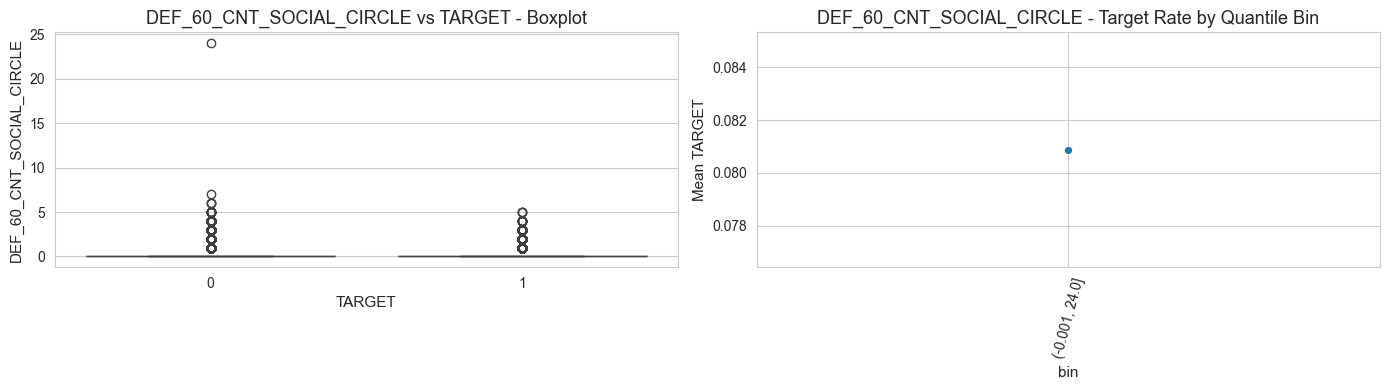

In [81]:
display(Markdown("### 11.2 Discrete Numeric Features vs Target"))

for col in important_discrete_features[:MAX_NUMERIC_TARGET_PLOTS]:
    plot_numeric_vs_target(train_df, col, TARGET_COL, q=5)

### 11.3 Categorical Features vs Target

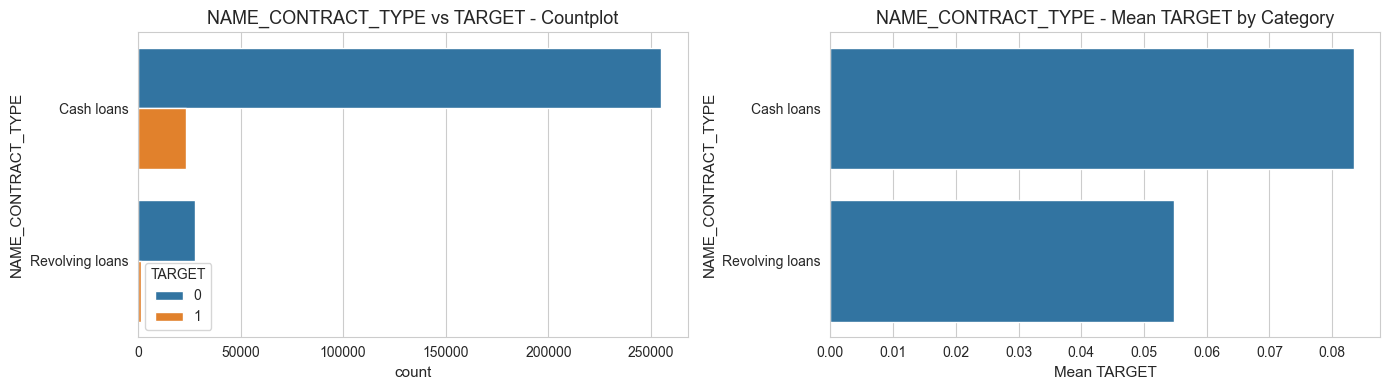

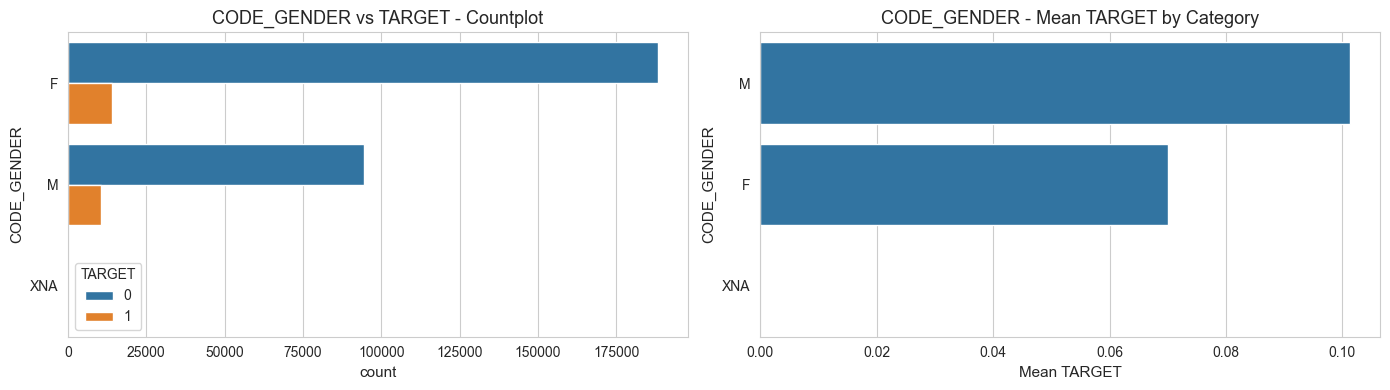

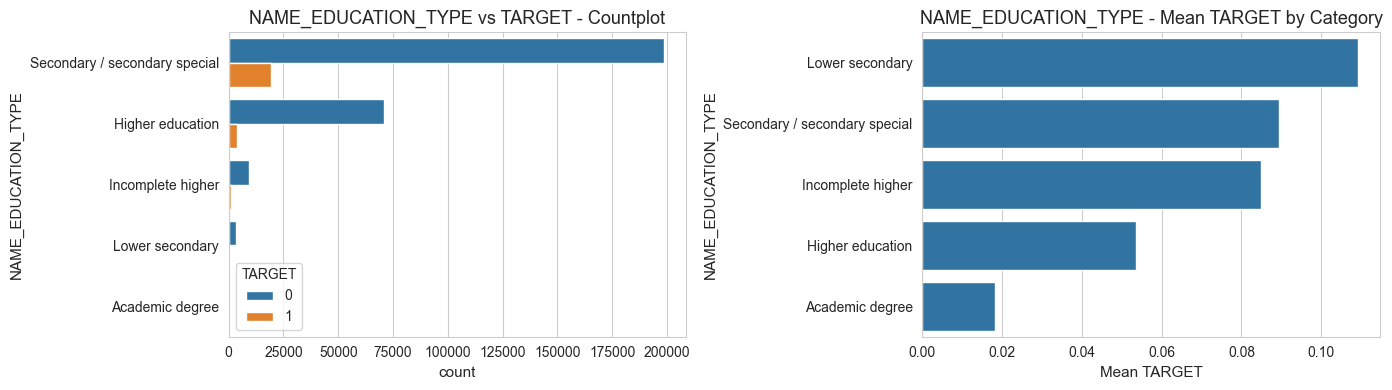

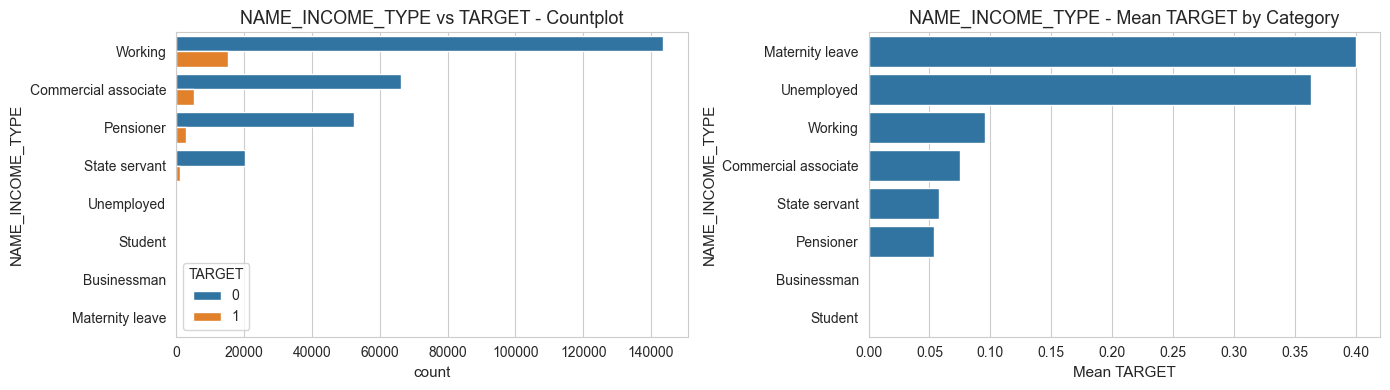

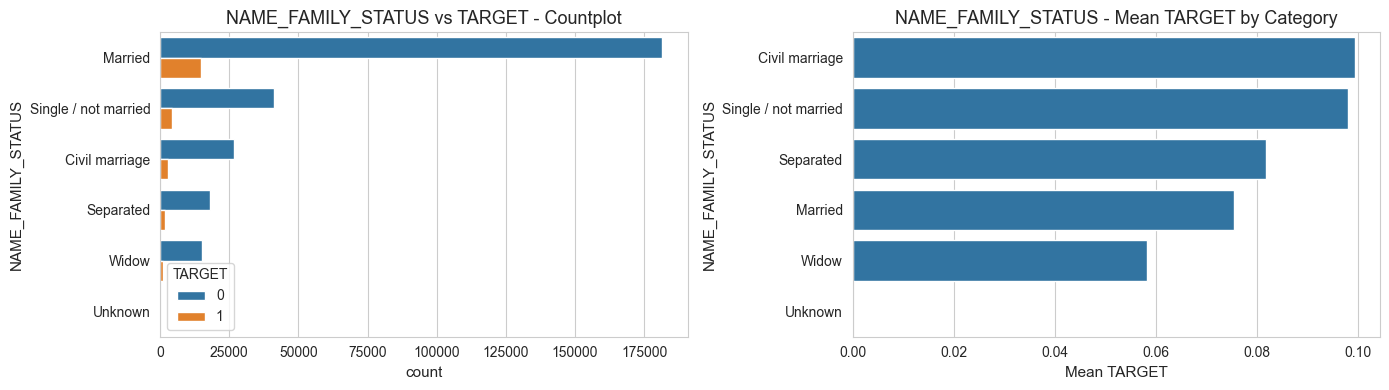

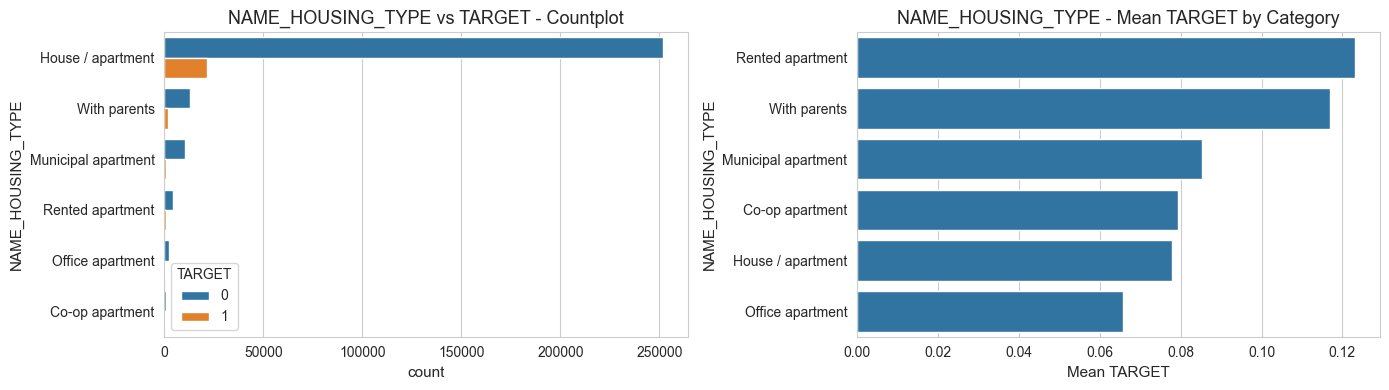

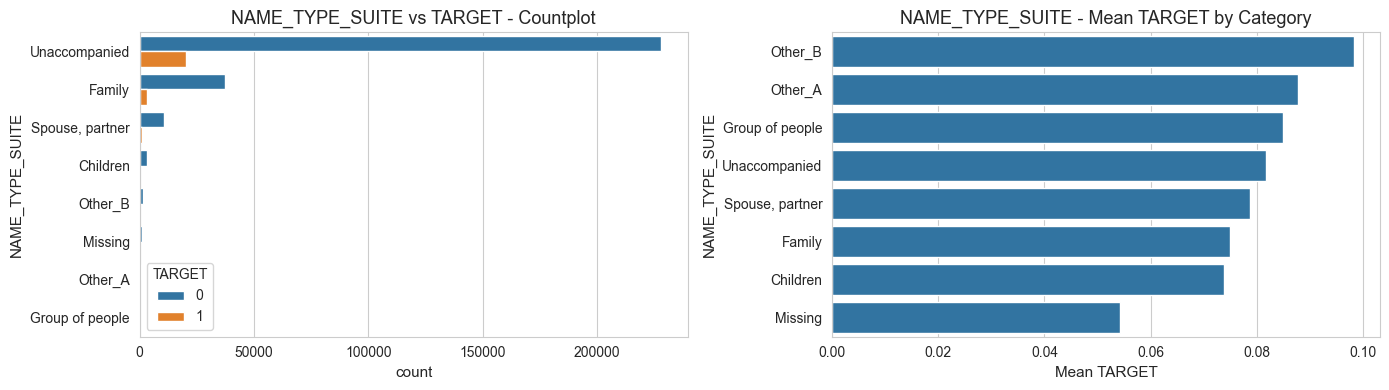

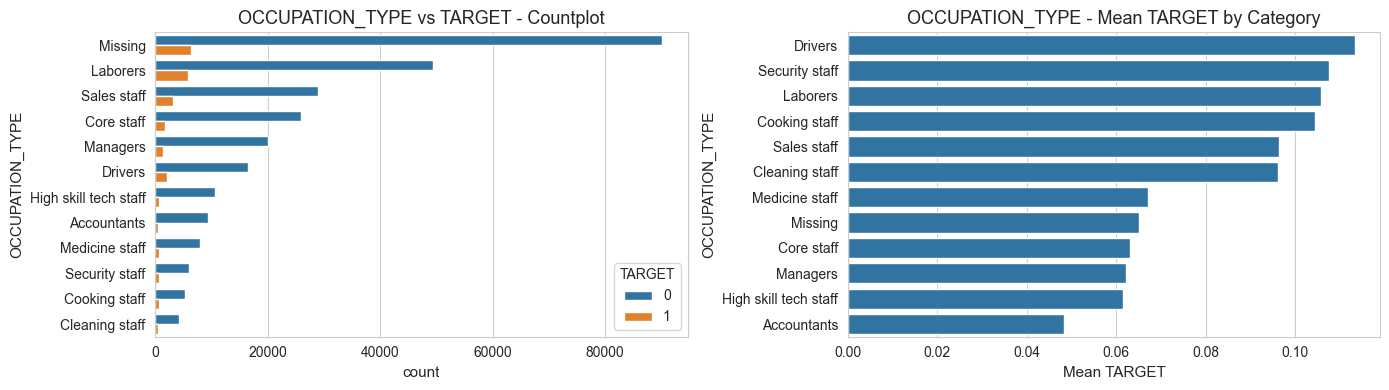

In [82]:
display(Markdown("### 11.3 Categorical Features vs Target"))

for col in important_categorical_features[:MAX_CATEGORICAL_TARGET_PLOTS]:
    plot_categorical_vs_target(train_df, col, TARGET_COL, top_n=12)

### 11.4 Numeric Feature Correlation with Target

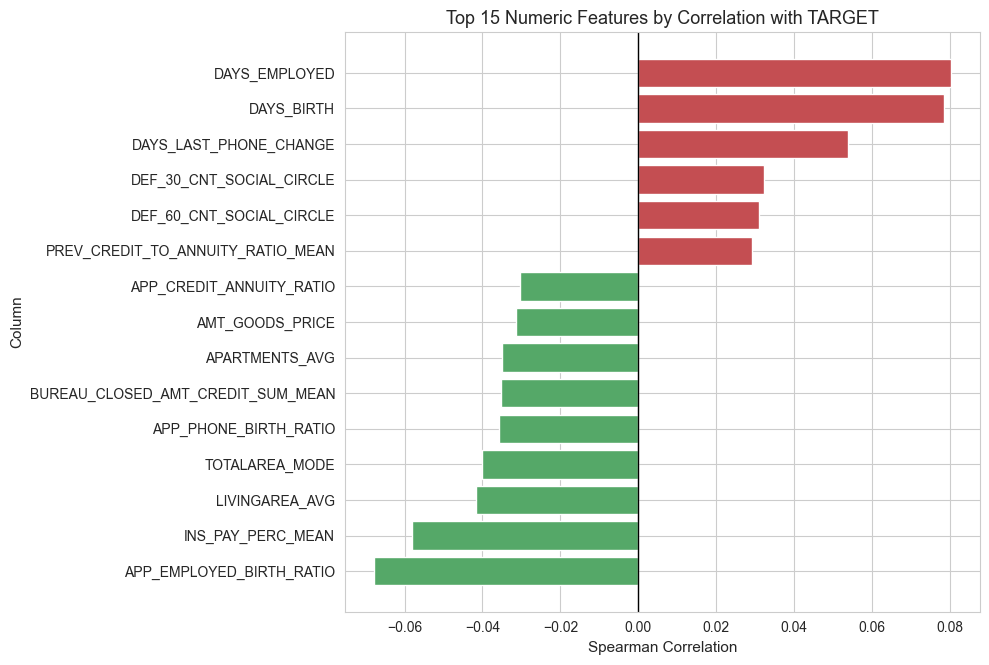

,column,corr,abs_corr,missing_pct
0,DAYS_EMPLOYED,0.0803,0.0803,18.0072
1,DAYS_BIRTH,0.0783,0.0783,0.0000
2,APP_EMPLOYED_BIRTH_RATIO,-0.0679,0.0679,18.0072
3,INS_PAY_PERC_MEAN,-0.0582,0.0582,5.1637
4,DAYS_LAST_PHONE_CHANGE,0.0537,0.0537,0.0003
5,LIVINGAREA_AVG,-0.0416,0.0416,50.1933
6,TOTALAREA_MODE,-0.0401,0.0401,48.2685
7,APP_PHONE_BIRTH_RATIO,-0.0359,0.0359,0.0003
8,BUREAU_CLOSED_AMT_CREDIT_SUM_MEAN,-0.0353,0.0353,25.1523
9,APARTMENTS_AVG,-0.0350,0.0350,50.7497


In [83]:
display(Markdown("### 11.4 Numeric Feature Correlation with Target"))

target_corr_candidates = list(dict.fromkeys(important_numeric_features + report_signal_features[:10]))
plot_target_correlation_bar(train_df, target_corr_candidates, TARGET_COL, top_n=15)


### 11.5 Categorical Interaction Heatmaps vs Target

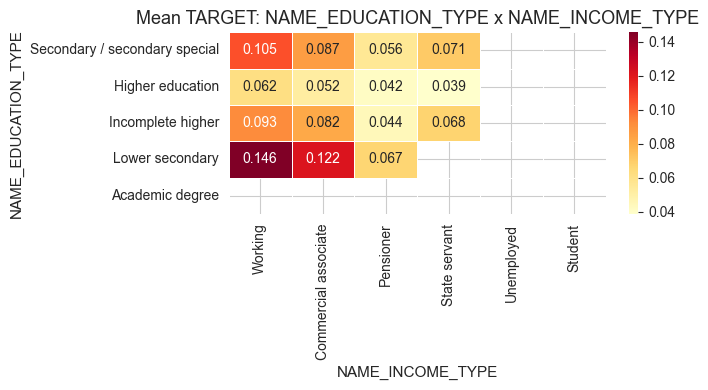

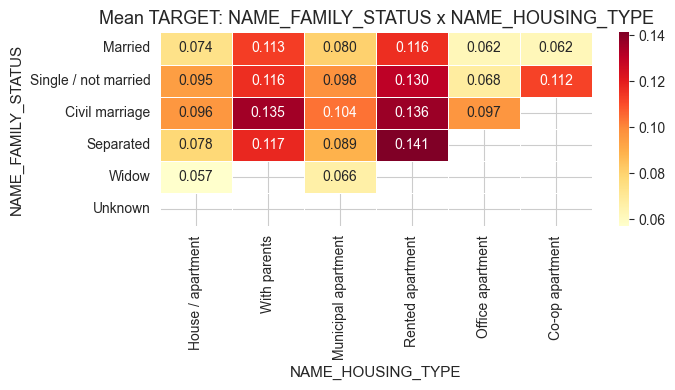

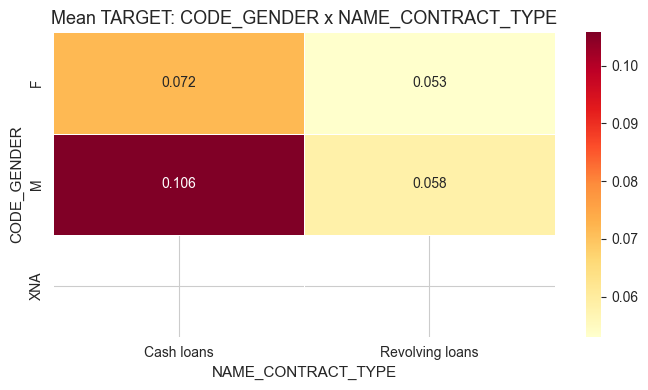

In [84]:
display(Markdown("### 11.5 Categorical Interaction Heatmaps vs Target"))

categorical_heatmap_pairs = [
    ("NAME_EDUCATION_TYPE", "NAME_INCOME_TYPE"),
    ("NAME_FAMILY_STATUS", "NAME_HOUSING_TYPE"),
    ("CODE_GENDER", "NAME_CONTRACT_TYPE")
]

for row_col, col_col in categorical_heatmap_pairs:
    plot_categorical_target_heatmap(train_df, row_col, col_col, TARGET_COL)


## 12. Selected Feature-to-Feature Relationship Analysis

In [85]:
# Selected scatter pairs for a time-efficient and meaningful EDA
scatter_pairs = [
    ("AMT_CREDIT", "AMT_ANNUITY"),
    ("AMT_CREDIT", "AMT_INCOME_TOTAL"),
    ("AMT_GOODS_PRICE", "AMT_CREDIT"),
    ("APP_CREDIT_INCOME_RATIO", "APP_ANNUITY_INCOME_RATIO"),
    ("APP_CREDIT_ANNUITY_RATIO", "AMT_ANNUITY"),
    ("DAYS_BIRTH", "DAYS_EMPLOYED"),
    ("DAYS_EMPLOYED", "DAYS_LAST_PHONE_CHANGE"),
    ("OBS_30_CNT_SOCIAL_CIRCLE", "DEF_30_CNT_SOCIAL_CIRCLE"),
    ("OBS_60_CNT_SOCIAL_CIRCLE", "DEF_60_CNT_SOCIAL_CIRCLE"),
    ("APARTMENTS_AVG", "LIVINGAREA_AVG"),
    ("TOTALAREA_MODE", "LIVINGAREA_AVG"),
    ("YEARS_BUILD_AVG", "YEARS_BEGINEXPLUATATION_AVG"),
    ("BUREAU_CLOSED_AMT_CREDIT_SUM_MEAN", "BUREAU_CLOSED_DAYS_CREDIT_MEAN"),
    ("REFUSED_AMT_APPLICATION_MEAN", "REFUSED_AMT_CREDIT_MEAN"),
    ("PREV_AMT_GOODS_PRICE_MEAN", "PREV_AMT_CREDIT_MEAN"),
    ("INS_AMT_INSTALMENT_MEAN", "INS_AMT_PAYMENT_SUM"),
    ("INS_PAY_PERC_MEAN", "INS_DBD_MEAN"),
    ("CC_PAYMENT_TOTAL_RATIO_MEAN", "CC_PAYMENT_MIN_RATIO_MEAN")
]

available_scatter_pairs = [(x, y) for x, y in scatter_pairs if x in train_df.columns and y in train_df.columns]
print("Available scatter pairs:", len(available_scatter_pairs))
print(available_scatter_pairs)

Available scatter pairs: 18
[('AMT_CREDIT', 'AMT_ANNUITY'), ('AMT_CREDIT', 'AMT_INCOME_TOTAL'), ('AMT_GOODS_PRICE', 'AMT_CREDIT'), ('APP_CREDIT_INCOME_RATIO', 'APP_ANNUITY_INCOME_RATIO'), ('APP_CREDIT_ANNUITY_RATIO', 'AMT_ANNUITY'), ('DAYS_BIRTH', 'DAYS_EMPLOYED'), ('DAYS_EMPLOYED', 'DAYS_LAST_PHONE_CHANGE'), ('OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE'), ('OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE'), ('APARTMENTS_AVG', 'LIVINGAREA_AVG'), ('TOTALAREA_MODE', 'LIVINGAREA_AVG'), ('YEARS_BUILD_AVG', 'YEARS_BEGINEXPLUATATION_AVG'), ('BUREAU_CLOSED_AMT_CREDIT_SUM_MEAN', 'BUREAU_CLOSED_DAYS_CREDIT_MEAN'), ('REFUSED_AMT_APPLICATION_MEAN', 'REFUSED_AMT_CREDIT_MEAN'), ('PREV_AMT_GOODS_PRICE_MEAN', 'PREV_AMT_CREDIT_MEAN'), ('INS_AMT_INSTALMENT_MEAN', 'INS_AMT_PAYMENT_SUM'), ('INS_PAY_PERC_MEAN', 'INS_DBD_MEAN'), ('CC_PAYMENT_TOTAL_RATIO_MEAN', 'CC_PAYMENT_MIN_RATIO_MEAN')]


### 12.1 Selected Scatterplots

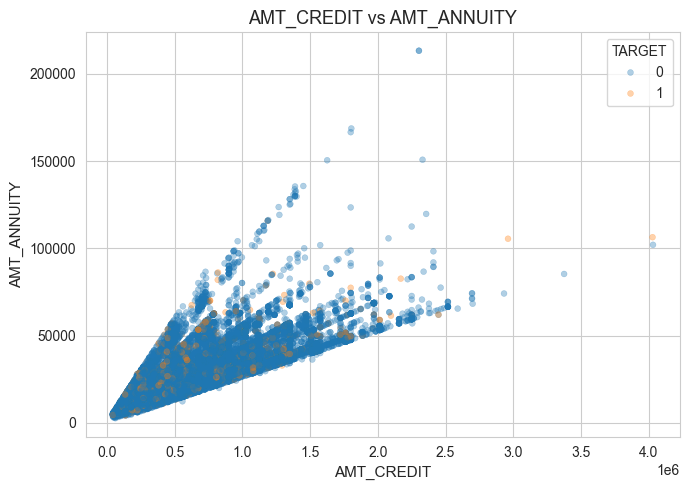

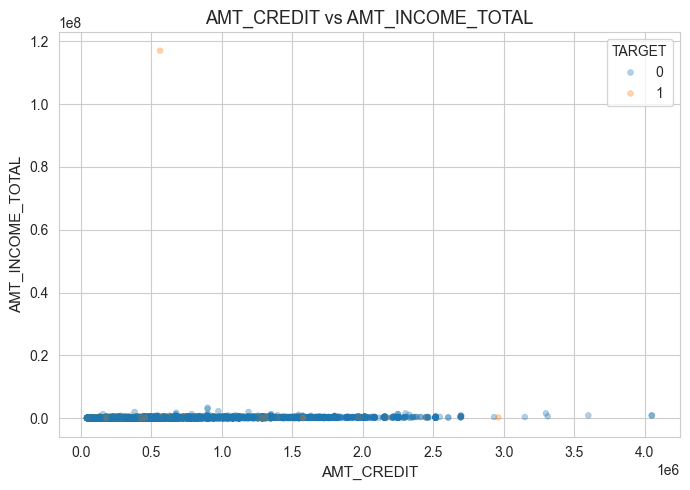

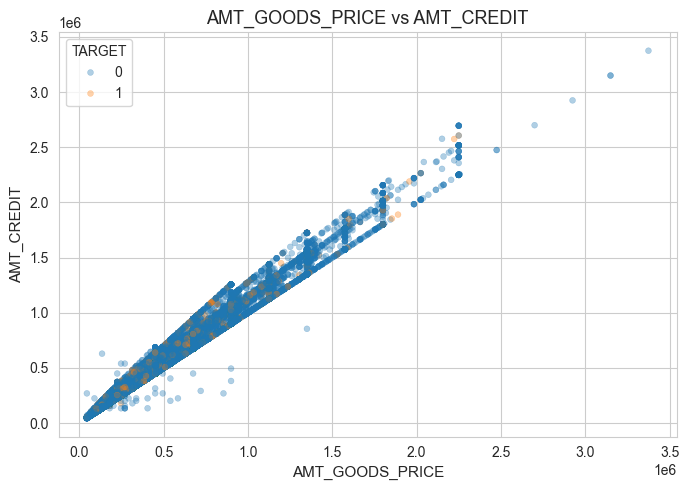

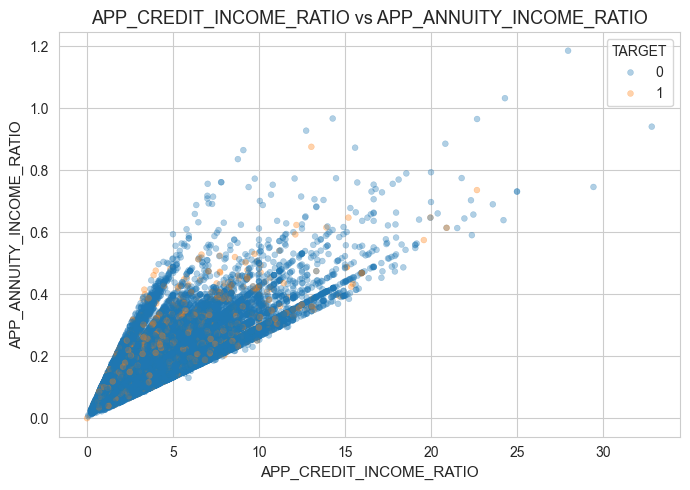

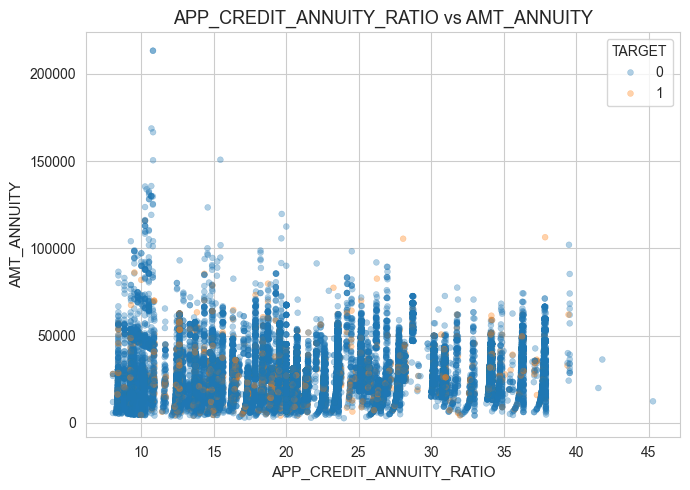

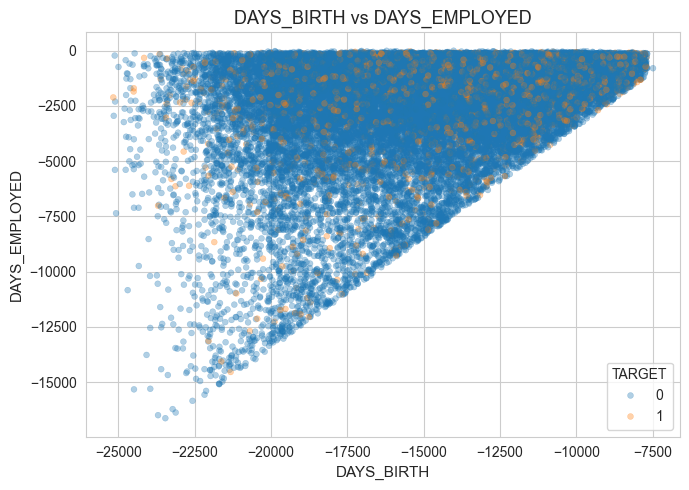

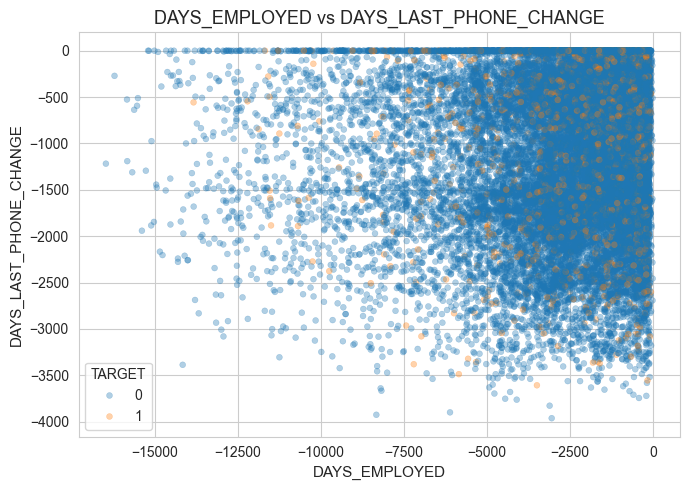

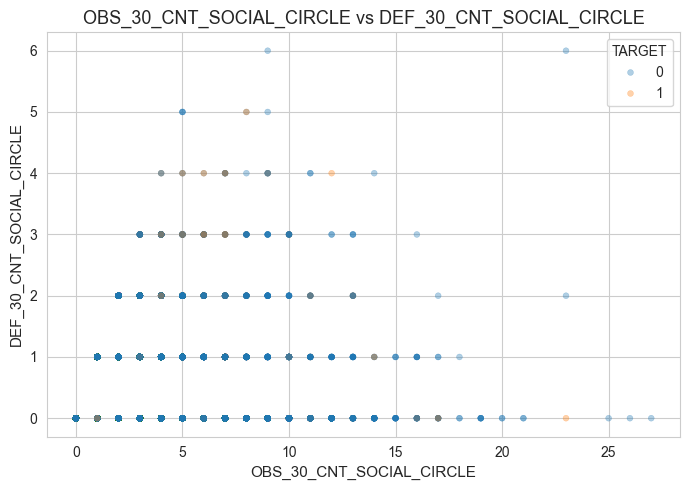

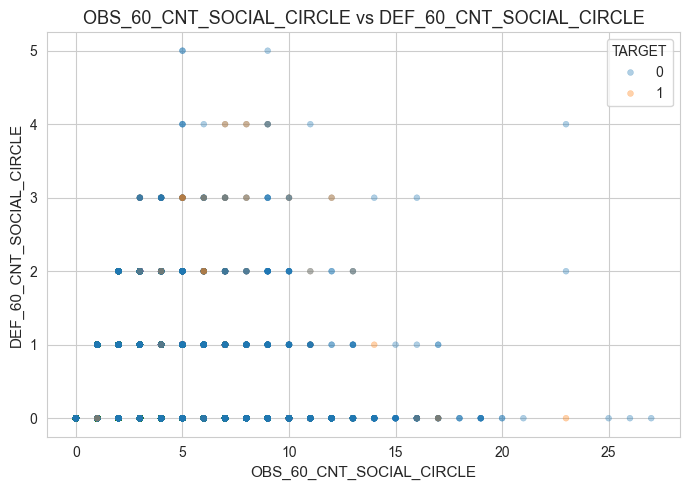

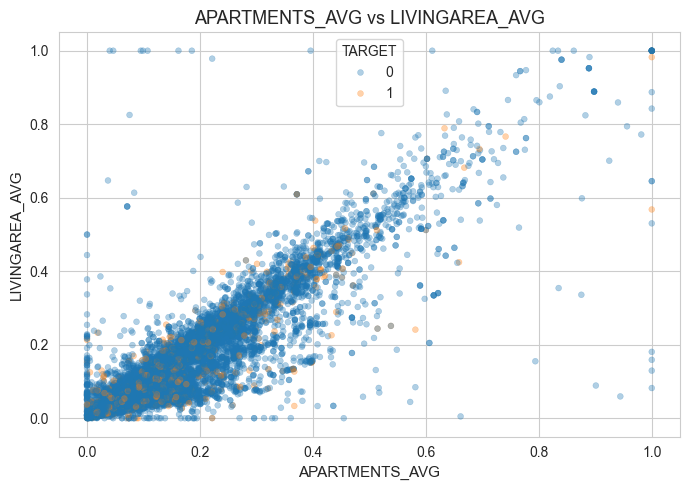

In [86]:
display(Markdown("### 12.1 Selected Scatterplots"))

for x_col, y_col in available_scatter_pairs[:10]:
    plot_scatter_pair(train_df, x_col, y_col, hue_col=TARGET_COL)

### 12.2 Density Views for Key Numeric Pairs

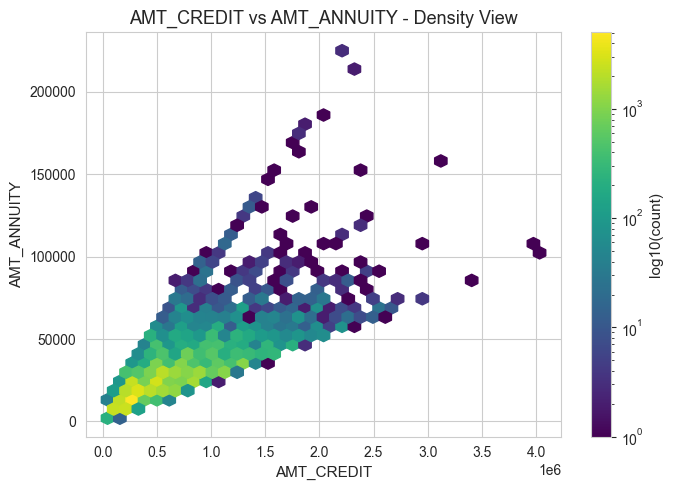

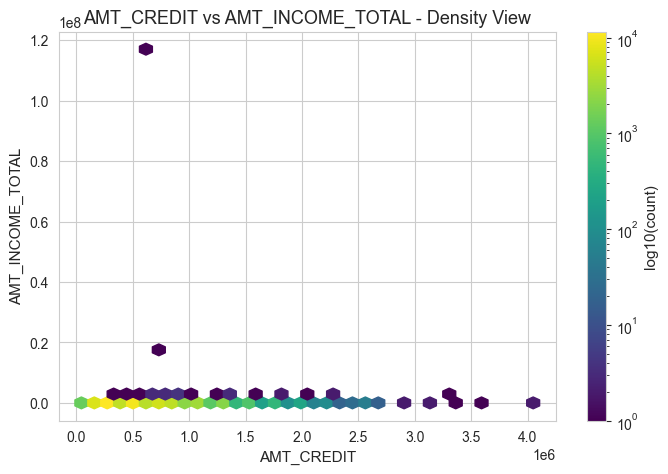

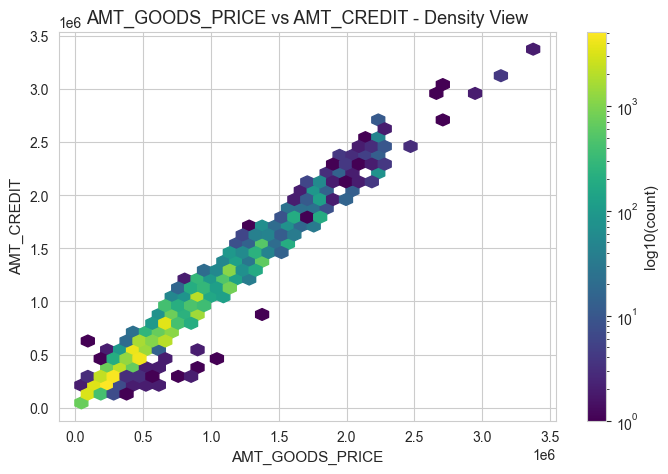

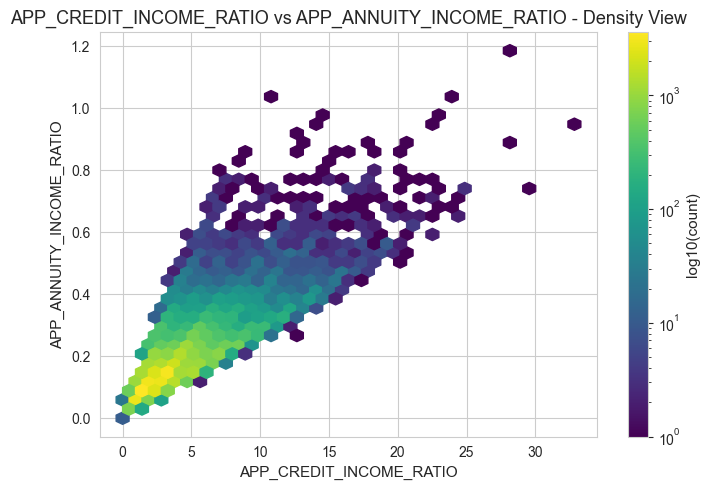

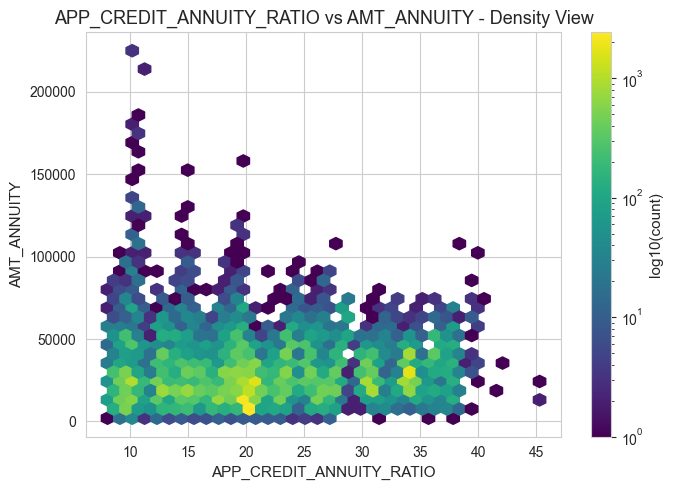

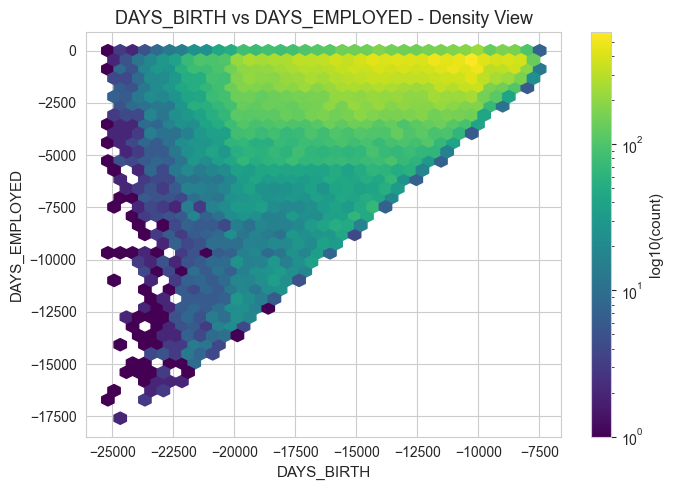

In [87]:
display(Markdown("### 12.2 Density Views for Key Numeric Pairs"))

for x_col, y_col in available_scatter_pairs[:6]:
    plot_density_pair(train_df, x_col, y_col)


## 13. Correlation and Redundancy Check

In [88]:
core_corr_features = existing_cols(train_df, [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "APP_ANNUITY_INCOME_RATIO",
    "APP_CREDIT_INCOME_RATIO",
    "APP_CREDIT_ANNUITY_RATIO",
    "APP_INCOME_PER_PERSON",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "DAYS_LAST_PHONE_CHANGE"
])

social_corr_features = existing_cols(train_df, [
    "DEF_30_CNT_SOCIAL_CIRCLE",
    "DEF_60_CNT_SOCIAL_CIRCLE",
    "OBS_30_CNT_SOCIAL_CIRCLE",
    "OBS_60_CNT_SOCIAL_CIRCLE",
    "AMT_REQ_CREDIT_BUREAU_DAY",
    "AMT_REQ_CREDIT_BUREAU_HOUR",
    "AMT_REQ_CREDIT_BUREAU_WEEK",
    "AMT_REQ_CREDIT_BUREAU_MON",
    "AMT_REQ_CREDIT_BUREAU_QRT",
    "AMT_REQ_CREDIT_BUREAU_YEAR"
])

housing_corr_features = existing_cols(train_df, [
    "TOTALAREA_MODE",
    "APARTMENTS_AVG",
    "LIVINGAREA_AVG",
    "NONLIVINGAREA_AVG",
    "BASEMENTAREA_AVG",
    "ENTRANCES_AVG",
    "ELEVATORS_AVG",
    "FLOORSMAX_AVG",
    "YEARS_BEGINEXPLUATATION_AVG",
    "YEARS_BUILD_AVG"
])

history_corr_features = existing_cols(train_df, [
    "BUREAU_CLOSED_AMT_CREDIT_SUM_MEAN",
    "BUREAU_CLOSED_AMT_CREDIT_SUM_SUM",
    "BUREAU_CLOSED_DAYS_CREDIT_MEAN",
    "PREV_AMT_GOODS_PRICE_MEAN",
    "PREV_AMT_CREDIT_MEAN",
    "PREV_CREDIT_TO_ANNUITY_RATIO_MEAN",
    "REFUSED_AMT_APPLICATION_MEAN",
    "REFUSED_AMT_CREDIT_MEAN",
    "INS_AMT_INSTALMENT_MEAN",
    "INS_PAY_PERC_MEAN",
    "CC_PAYMENT_TOTAL_RATIO_MEAN"
])

### 13.1 Correlation Heatmap - Core Features

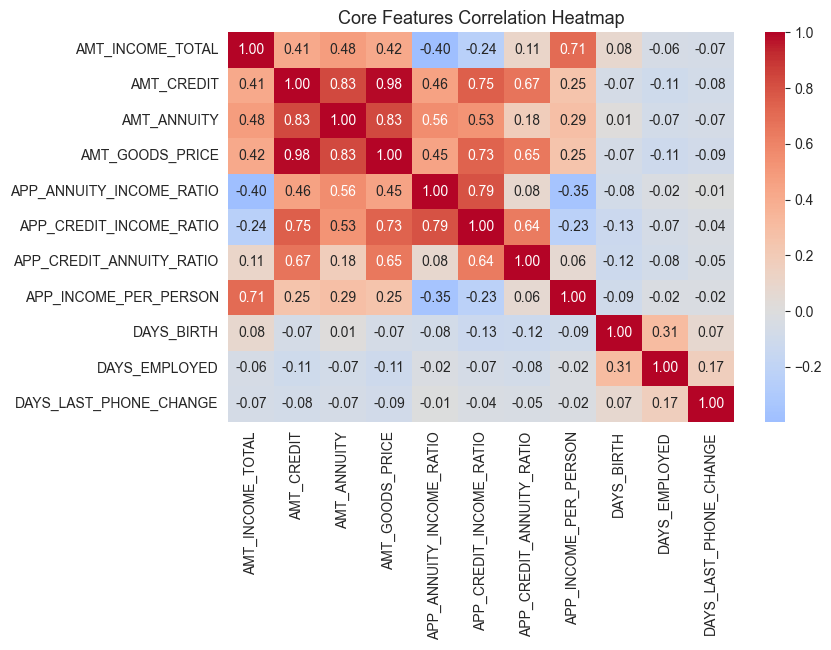

In [89]:
display(Markdown("### 13.1 Correlation Heatmap - Core Features"))
plot_corr_heatmap(train_df, core_corr_features, title="Core Features Correlation Heatmap")

### 13.2 Correlation Heatmap - Social and Inquiry Features

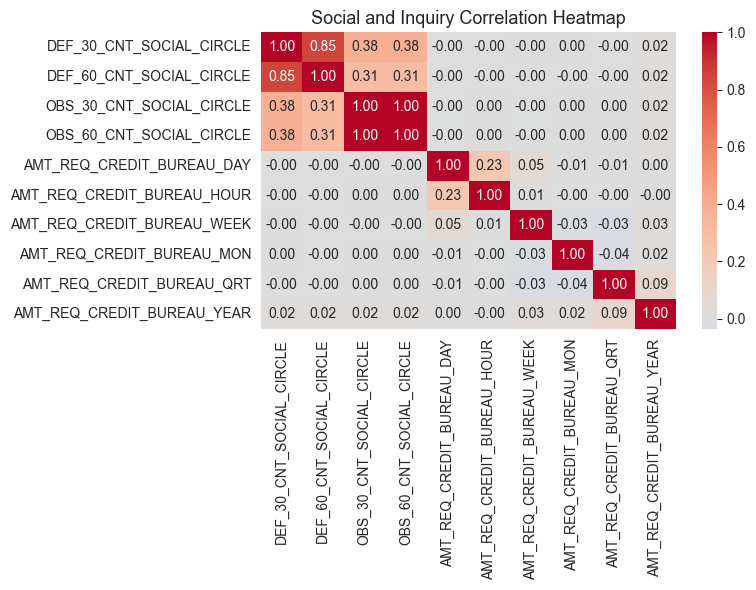

In [90]:
display(Markdown("### 13.2 Correlation Heatmap - Social and Inquiry Features"))
plot_corr_heatmap(train_df, social_corr_features, title="Social and Inquiry Correlation Heatmap")

### 13.3 Correlation Heatmap - Housing Features

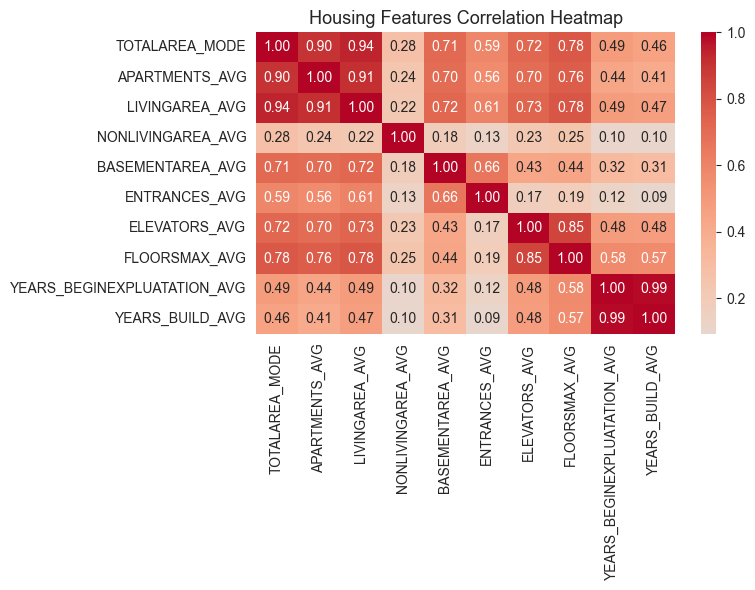

In [91]:
display(Markdown("### 13.3 Correlation Heatmap - Housing Features"))
plot_corr_heatmap(train_df, housing_corr_features, title="Housing Features Correlation Heatmap")

### 13.4 Correlation Heatmap - Historical Aggregate Features

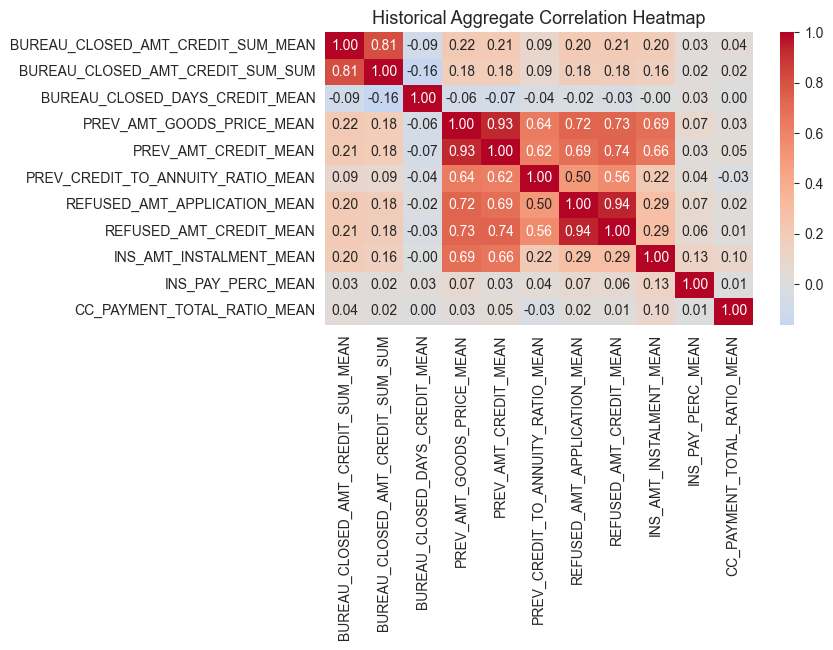

In [92]:
display(Markdown("### 13.4 Correlation Heatmap - Historical Aggregate Features"))
plot_corr_heatmap(train_df, history_corr_features, title="Historical Aggregate Correlation Heatmap")

In [93]:
display(Markdown("### 13.5 Highly Correlated Feature Pairs"))

all_corr_candidates = sorted(set(core_corr_features + social_corr_features + housing_corr_features + history_corr_features))
high_corr_pairs_df = get_high_corr_pairs(train_df, all_corr_candidates, threshold=0.90, method="spearman")
display(high_corr_pairs_df.head(50))

### 13.5 Highly Correlated Feature Pairs

,feature_1,feature_2,corr
0,OBS_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,0.9973
1,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,0.9871
2,AMT_CREDIT,AMT_GOODS_PRICE,0.9849
3,LIVINGAREA_AVG,TOTALAREA_MODE,0.9395
4,REFUSED_AMT_APPLICATION_MEAN,REFUSED_AMT_CREDIT_MEAN,0.9366
5,PREV_AMT_CREDIT_MEAN,PREV_AMT_GOODS_PRICE_MEAN,0.9279
6,APARTMENTS_AVG,LIVINGAREA_AVG,0.9060


## 14. Feature Engineering Roadmap

In [94]:
display(Markdown("### 14.1 Build a Practical Feature Engineering Plan"))

fe_plan_rows = []

# Missing indicators
for col in missing_df[missing_df["missing_pct"] >= 10]["column"].tolist():
    if col in train_df.columns:
        fe_plan_rows.append({
            "feature": col,
            "suggested_action": "create_missing_indicator",
            "reason": "Feature has meaningful missingness and may carry signal."
        })

# Log transform candidates from important numeric features
for col in important_continuous_features:
    if col in train_df.columns:
        temp = train_df[col].dropna()
        if not temp.empty and (temp >= 0).all():
            skew_val = temp.skew()
            if abs(skew_val) >= 1:
                fe_plan_rows.append({
                    "feature": col,
                    "suggested_action": "log1p_transform",
                    "reason": f"Feature is positively valued and skewed (skew={skew_val:.2f})."
                })

# Outlier clipping candidates
for col in important_numeric_features:
    if col in train_df.columns and pd.api.types.is_numeric_dtype(train_df[col]):
        temp = train_df[col].dropna()
        if not temp.empty:
            q1 = temp.quantile(0.25)
            q3 = temp.quantile(0.75)
            iqr = q3 - q1
            if iqr > 0:
                lower = q1 - 1.5 * iqr
                upper = q3 + 1.5 * iqr
                outlier_rate = ((temp < lower) | (temp > upper)).mean() * 100
                if outlier_rate >= 1.5:
                    fe_plan_rows.append({
                        "feature": col,
                        "suggested_action": "clip_or_winsorize",
                        "reason": f"Feature shows notable outliers (approx outlier rate={outlier_rate:.2f}%)."
                    })

# Categorical encoding plan
for col in important_categorical_features:
    if col in train_df.columns:
        nunique = train_df[col].nunique(dropna=True)
        if nunique <= 10:
            action = "one_hot_encoding"
            reason = f"Low cardinality categorical feature (nunique={nunique})."
        else:
            action = "frequency_or_target_encoding"
            reason = f"Higher cardinality categorical feature (nunique={nunique})."
        fe_plan_rows.append({
            "feature": col,
            "suggested_action": action,
            "reason": reason
        })

# Binning plan
for col in existing_cols(train_df, [
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "APP_CREDIT_ANNUITY_RATIO",
    "APP_ANNUITY_INCOME_RATIO",
    "DAYS_LAST_PHONE_CHANGE",
    "CNT_FAM_MEMBERS",
    "CNT_CHILDREN"
]):
    fe_plan_rows.append({
        "feature": col,
        "suggested_action": "binning_candidate",
        "reason": "Can be tested for monotonic or grouped risk patterns."
    })

fe_plan_df = pd.DataFrame(fe_plan_rows).drop_duplicates().reset_index(drop=True)
display(fe_plan_df.head(100))

### 14.1 Build a Practical Feature Engineering Plan

,feature,suggested_action,reason
0,CC_PAYMENT_MIN_RATIO_MAX,create_missing_indicator,Feature has meaningful missingness and may car...
1,CC_PAYMENT_MIN_RATIO_MEAN,create_missing_indicator,Feature has meaningful missingness and may car...
2,CC_PAYMENT_TOTAL_RATIO_MAX,create_missing_indicator,Feature has meaningful missingness and may car...
3,CC_PAYMENT_TOTAL_RATIO_MEAN,create_missing_indicator,Feature has meaningful missingness and may car...
4,CC_AMT_PAYMENT_CURRENT_MAX,create_missing_indicator,Feature has meaningful missingness and may car...
5,CC_AMT_PAYMENT_CURRENT_MEAN,create_missing_indicator,Feature has meaningful missingness and may car...
6,CC_AMT_DRAWINGS_ATM_CURRENT_MAX,create_missing_indicator,Feature has meaningful missingness and may car...
7,CC_AMT_DRAWINGS_ATM_CURRENT_MEAN,create_missing_indicator,Feature has meaningful missingness and may car...
8,CC_AMT_DRAWINGS_POS_CURRENT_MAX,create_missing_indicator,Feature has meaningful missingness and may car...
9,CC_AMT_DRAWINGS_POS_CURRENT_MEAN,create_missing_indicator,Feature has meaningful missingness and may car...


In [95]:
display(Markdown("### 14.2 Manual Feature Engineering Ideas"))

manual_fe_ideas = pd.DataFrame({
    "feature_family": [
        "History availability flags",
        "Social inquiry summary",
        "Housing trio consolidation",
        "Ratio stabilization",
        "Missingness signal",
        "Redundancy reduction"
    ],
    "example_features": [
        "HAS_BUREAU_HISTORY, HAS_PREV_HISTORY, HAS_REFUSED_HISTORY, HAS_CC_HISTORY",
        "TOTAL_SOCIAL_OBS, TOTAL_SOCIAL_DEF, TOTAL_BUREAU_REQ",
        "mean/std/range over AVG-MEDI-MODE feature trios",
        "log1p on income, credit, annuity, selected ratios",
        "is_missing flags for high-missing variables",
        "drop one of highly correlated pairs or consolidate them"
    ],
    "why_useful": [
        "Missing history itself may carry customer behavior signal.",
        "Summaries can simplify multiple sparse inquiry columns.",
        "The trio groups are likely redundant and can be summarized.",
        "Stabilizes heavy skew and reduces outlier impact.",
        "Missingness may be informative instead of noise.",
        "Reduces multicollinearity and simplifies the model."
    ]
})

display(manual_fe_ideas)

### 14.2 Manual Feature Engineering Ideas

,feature_family,example_features,why_useful
0,History availability flags,"HAS_BUREAU_HISTORY, HAS_PREV_HISTORY, HAS_REFU...",Missing history itself may carry customer beha...
1,Social inquiry summary,"TOTAL_SOCIAL_OBS, TOTAL_SOCIAL_DEF, TOTAL_BURE...",Summaries can simplify multiple sparse inquiry...
2,Housing trio consolidation,mean/std/range over AVG-MEDI-MODE feature trios,The trio groups are likely redundant and can b...
3,Ratio stabilization,"log1p on income, credit, annuity, selected ratios",Stabilizes heavy skew and reduces outlier impact.
4,Missingness signal,is_missing flags for high-missing variables,Missingness may be informative instead of noise.
5,Redundancy reduction,drop one of highly correlated pairs or consoli...,Reduces multicollinearity and simplifies the m...


## 15. Optional Export of EDA Tables

In [96]:
# Optional: export key EDA tables next to the train file directory
EXPORT_EDA_TABLES = False

if EXPORT_EDA_TABLES:
    export_dir = Path(TRAIN_FILE_PATH).resolve().parent / "eda_outputs"
    export_dir.mkdir(parents=True, exist_ok=True)

    missing_df.to_csv(export_dir / "missing_summary.csv", index=False)
    group_summary.to_csv(export_dir / "group_summary.csv", index=False)
    zero_summary_df.to_csv(export_dir / "zero_summary.csv", index=False)
    high_corr_pairs_df.to_csv(export_dir / "high_corr_pairs.csv", index=False)
    fe_plan_df.to_csv(export_dir / "feature_engineering_plan.csv", index=False)

    print(f"EDA tables exported to: {export_dir}")
else:
    print("Export is disabled. Set EXPORT_EDA_TABLES = True if you want to save EDA tables.")

Export is disabled. Set EXPORT_EDA_TABLES = True if you want to save EDA tables.


## 16. Final Summary

### 16.1 What this notebook completed

This notebook completed the following:

1. Loaded train, test, and structural audit report files
2. Validated the core dataset structure
3. Reused structural audit findings instead of repeating low-value checks
4. Built practical feature groups
5. Shortlisted important features for focused EDA
6. Reviewed missing values and missing-vs-target behavior
7. Performed univariate analysis for selected numeric and categorical features
8. Performed bivariate analysis with the target
9. Created selected feature-to-feature scatterplots
10. Reviewed correlation and redundancy
11. Built a practical feature engineering roadmap

### 16.2 Suggested next notebook

The next notebook can focus on:

- preprocessing pipeline
- missing value treatment
- encoding
- transformation
- feature selection
- baseline model training